# Python Final Project
#### X3 Group 12: Xier Shen, Yiyun Wu, Angela Kim

# Import Libraries & Files

In [1]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import folium
from matplotlib.patches import Patch

pd.options.display.precision = 2

In [2]:
#read files
locations_df = pd.read_csv('Locations.csv') #lists all the gas station locations
tanks_df = pd.read_csv('Tanks.csv') #contains information about tanks if each location
invoices_df = pd.read_csv('Invoices.csv') #Every delivery of each fuel type to all tanks of a location generates one invoice. 
fuel1_df = pd.read_csv('Fuel_Level_Part_1.csv') #contain fuel level information in each tank at frequent and mostly regular time stamps
fuel2_df = pd.read_csv('Fuel_Level_Part_2.csv') #contain fuel level information in each tank at frequent and mostly regular time stamps

# **Data Cleaning**

## 1.Rename Columns, change dates to datetime

In [3]:
#rename columns for locations_df
locations_df.rename(columns = {'Gas Station Location': 'station_location', 'Gas Station Name':'station_name', 'Gas Station Address':'station_address', 
                               'Gas Station Latitude': 'station_lat', 'Gas Station Longitude':'station_lon'}, inplace = True)

#rename columns for tanks_df
tanks_df.rename(columns = {'Tank ID': 'tank_id', 'Tank Location':'station_location', 'Tank Number': 'tank_num', 'Tank Type':'tank_type1', 'Tank Capacity':'tank_capa'},
                inplace = True)
#replace tank_type with actual values of each letter:  U for regular gas, D for Diesel, and P for premium
#to simplify it for you, you can consider `U` and `P` to be `G` (Gasoline) and `D` to be `D` (Diesel)
tanks_df['tank_type2'] = tanks_df['tank_type1'].replace({'U':'Gasoline', 'P':'Gasoline', 'D':'Diesel'})

#rename columns for invoices_df
invoices_df.rename(columns = {'Invoice Date':'invoice_date', 'Invoice ID': 'invoice_id', 'Invoice Gas Station Location':'station_location', 'Gross Purchase Cost':'purchased_cost',
                          'Amount Purchased':'purchased_amount', 'Fuel Type':'tank_type1'},
                   inplace = True)
# Change Invoice Date to datetime
invoices_df.info()
invoices_df['invoice_date'] = pd.to_datetime(invoices_df['invoice_date'])
invoices_df.info()
#create tank_type2 with tank_type1
invoices_df['tank_type2'] = invoices_df['tank_type1'].replace({'G':'Gasoline', 'D':'Diesel'})

#rename columns for fuel1_df
fuel1_df.rename(columns = {'Tank ID':'tank_id', 'Fuel Level':'fuel_level', 'Time stamp':'timestamp'}, inplace = True)
# change datetime dtype
fuel1_df.info()
fuel1_df['timestamp'] = pd.to_datetime(fuel1_df['timestamp'])
fuel1_df.info()

#rename columns for fuel2_df to match fuel1_df
fuel2_df.columns = fuel1_df.columns
# change datetime dtype
fuel2_df.info()
fuel2_df['timestamp'] = pd.to_datetime(fuel2_df['timestamp'])
fuel2_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2873 entries, 0 to 2872
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   invoice_date      2873 non-null   object 
 1   invoice_id        2832 non-null   float64
 2   station_location  2873 non-null   int64  
 3   purchased_cost    2831 non-null   float64
 4   purchased_amount  2831 non-null   float64
 5   tank_type1        2831 non-null   object 
dtypes: float64(3), int64(1), object(2)
memory usage: 134.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2873 entries, 0 to 2872
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   invoice_date      2873 non-null   datetime64[ns]
 1   invoice_id        2832 non-null   float64       
 2   station_location  2873 non-null   int64         
 3   purchased_cost    2831 non-null   float64       
 4   purchased_amount  2

## 2. Combine Datasets & Check for NA

### Merge `tanks_df` with `location_df` and check for missing values

tank_id             0
station_location    0
tank_num            0
tank_type1          0
tank_capa           0
tank_type2          0
station_name        0
station_address     0
station_lat         0
station_lon         0
dtype: int64

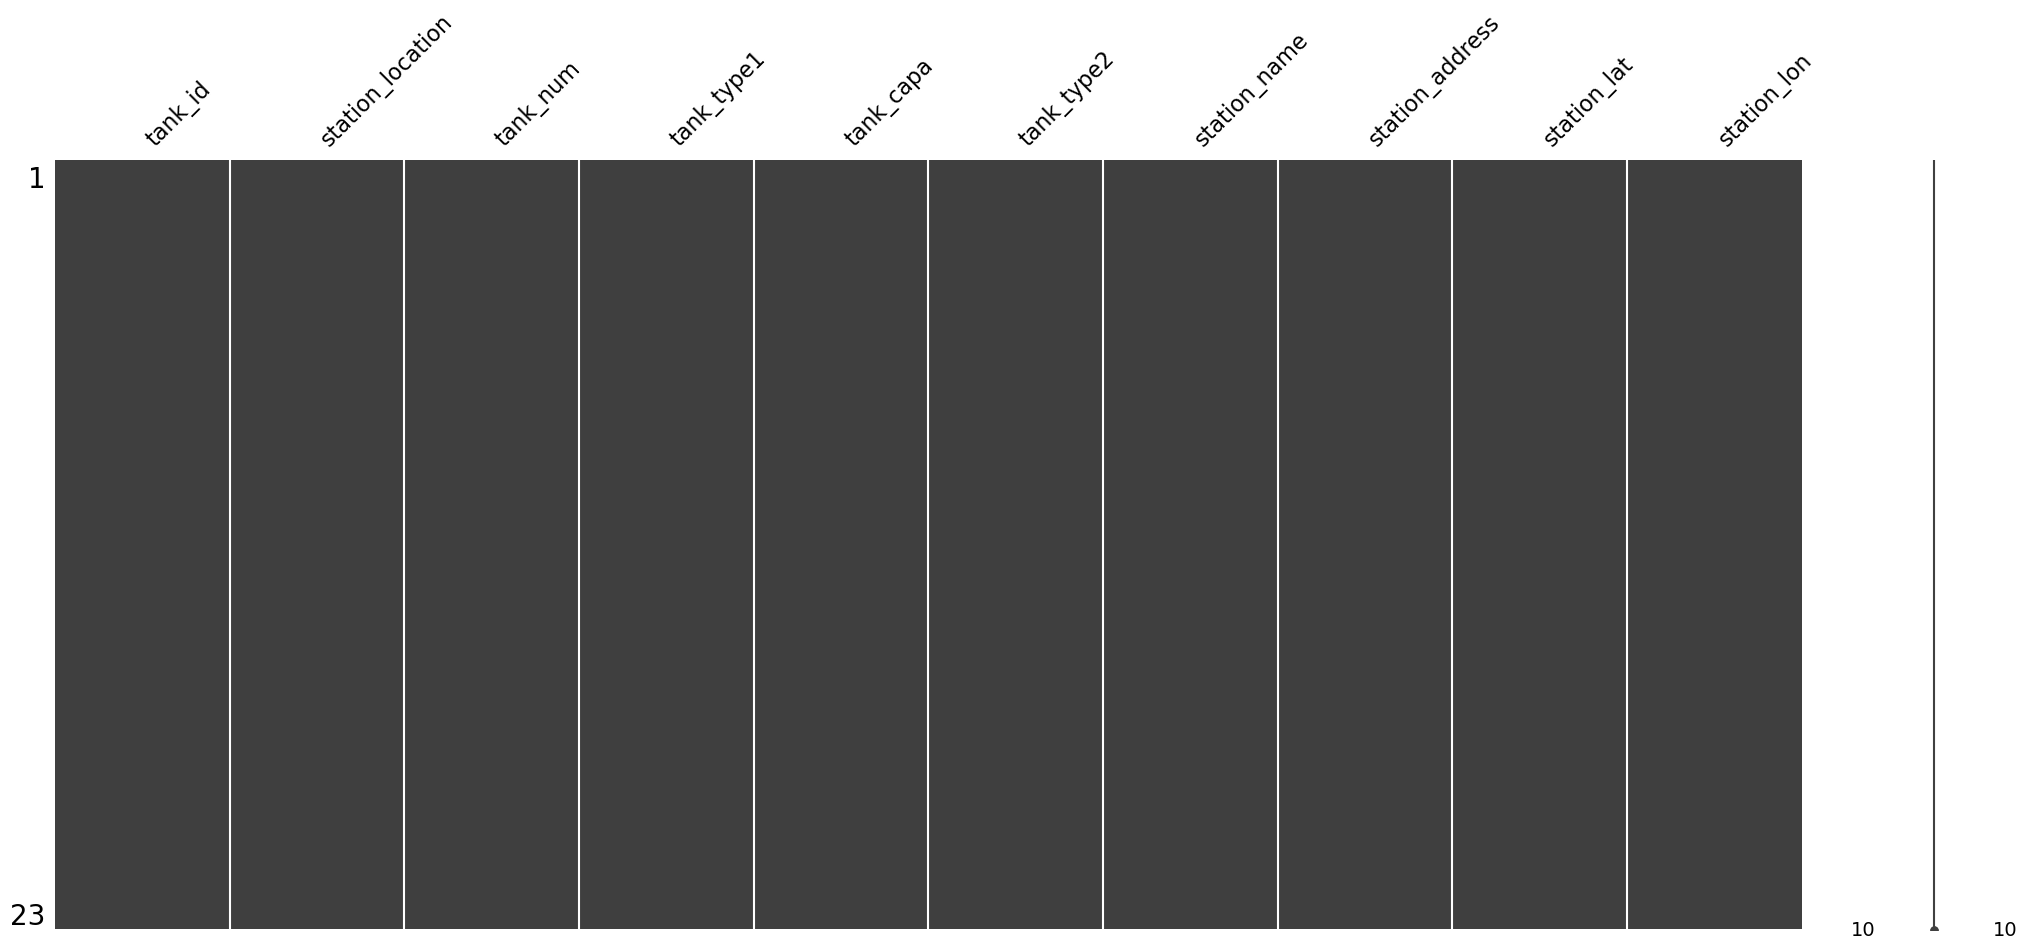

In [4]:
# Merge tanks_df and location_df
tanksloc_df = tanks_df.merge(locations_df, 
                                  on = 'station_location',
                                  how = 'left'
                                 )
tanksloc_df.head()

#check for missing values
msno.matrix(tanksloc_df)
tanksloc_df[tanksloc_df.isna().any(axis = 1)].count() #no missing values

### `invoices_df`: check for NA & add date columns

(2873, 7)

(2831, 8)

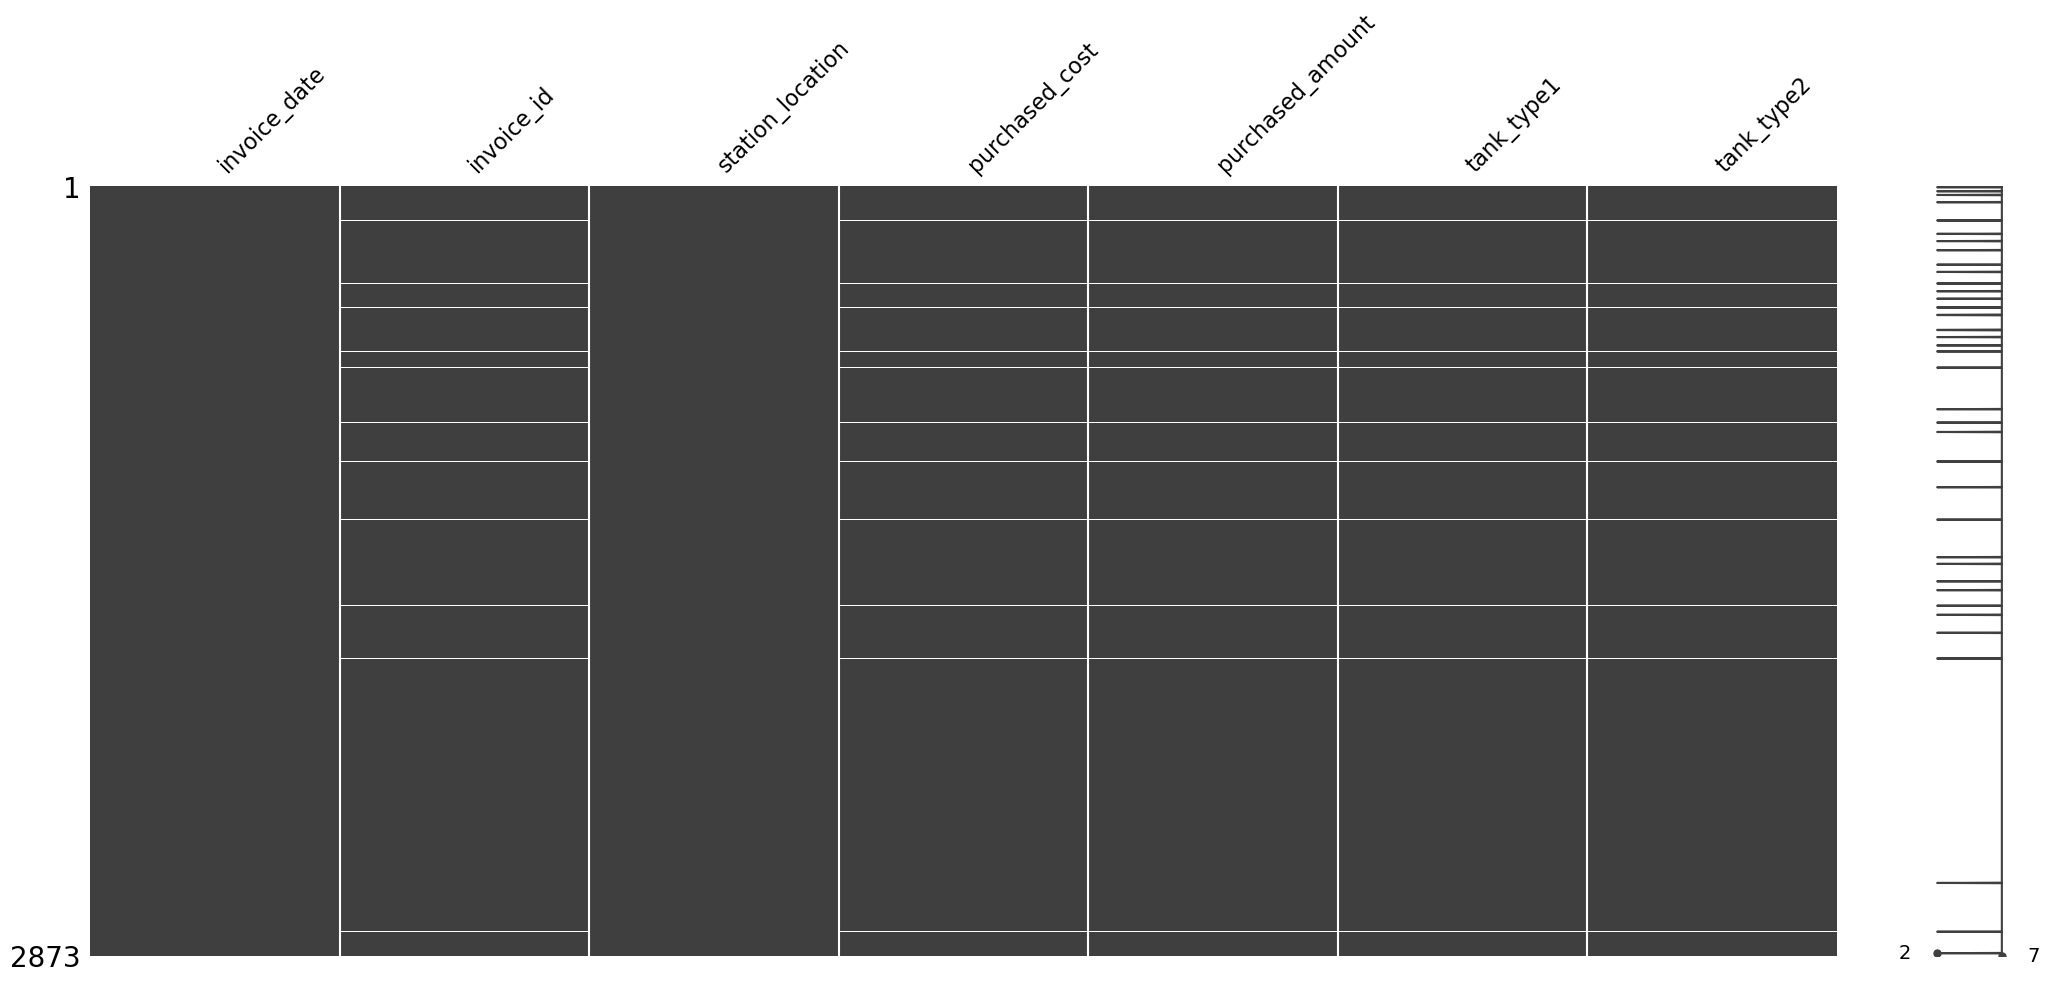

In [5]:
#check for NA, drop NA
msno.matrix(invoices_df)
display(invoices_df.shape)
invoices_df[invoices_df.isna().any(axis = 1)] #becuase most columns except for invoice date and location is missing, drop any row with at least one missing value
invoices_df2 = invoices_df.dropna(how = 'any').reset_index()
display(invoices_df2.shape)

In [6]:
#add date columns 
invoices_df2['Year'] = invoices_df2['invoice_date'].dt.year
invoices_df2['Month'] = invoices_df2['invoice_date'].dt.month
invoices_df2['Day'] = invoices_df2['invoice_date'].dt.day
invoices_df2['Day_dig'] = invoices_df2['invoice_date'].dt.dayofweek
invoices_df2['Weekday'] = invoices_df2['invoice_date'].dt.day_name()
invoices_df2.head(4)

,index,invoice_date,invoice_id,station_location,purchased_cost,purchased_amount,tank_type1,tank_type2,Year,Month,Day,Day_dig,Weekday
0,0,2017-01-02,10000.0,1,7570.82,6609.60,G,Gasoline,2017,1,2,0,Monday
1,1,2017-01-02,10001.0,1,12491.85,9338.74,D,Diesel,2017,1,2,0,Monday
2,3,2017-01-02,10002.0,2,17034.35,13377.82,D,Diesel,2017,1,2,0,Monday
3,5,2017-01-02,10003.0,2,12616.77,9432.11,D,Diesel,2017,1,2,0,Monday


### `fuel1_df` & `fuel2_df`: Check unique values for tank id

In [7]:
print(fuel1_df['tank_id'].unique())
print(fuel2_df['tank_id'].unique())

# Change fuel1_df = T12 to T12
fuel1_df[fuel1_df['tank_id'] == 'T12']
fuel1_df['tank_id'].loc[fuel1_df['tank_id'] == 'T12'] = 'T 12'

#fuel1_df['Tank ID'] = fuel1_df['Tank ID'].apply(lambda x: 'T 12' if x == 'T12' else x)
print(fuel1_df['tank_id'].unique())

['T 12' 'T12' 'T 13' 'T 15' 'T 17' 'T 19' 'T 21' 'T 23' 'T 24' 'T 28'
 'T 30' 'T 31']
['T 32' 'T 20' 'T 10' 'T 11' 'T 14' 'T 25' 'T 16' 'T 27' 'T 26' 'T 22'
 'T 18' 'T 29']
['T 12' 'T 13' 'T 15' 'T 17' 'T 19' 'T 21' 'T 23' 'T 24' 'T 28' 'T 30'
 'T 31']


/var/folders/nr/x6d82jnx1pn04_gdb8vr44sr0000gn/T/ipykernel_73119/1851626272.py:6: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  fuel1_df['tank_id'].loc[fuel1_df['tank_id'] == 'T12'] = 'T 12'
/var/folders/nr/x6d82jnx1pn04_gdb8vr44sr0000gn/T/i

### Concat `fuel1_df` & `fuel2_df`

In [8]:
#combine fuel1_df and fuel2_df into new df
fuel_df = pd.concat([fuel1_df,fuel2_df])
fuel_df.info()

#checking for missing values
fuel_df[fuel_df.isna().any(axis = 1)]
#because most inventory data for T 12 are in 15 second intervals, while rows 3 and 111 are not, dropping these rows with NA does not impact the data
fuel_df = fuel_df.dropna(how = 'any').reset_index()
fuel_df[fuel_df.isna().any(axis = 1)].count() 

<class 'pandas.core.frame.DataFrame'>
Index: 1859660 entries, 0 to 974508
Data columns (total 3 columns):
 #   Column      Dtype         
---  ------      -----         
 0   tank_id     object        
 1   fuel_level  float64       
 2   timestamp   datetime64[ns]
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 56.8+ MB


index         0
tank_id       0
fuel_level    0
timestamp     0
dtype: int64

### Merge `fuel_df` & `tanksloc_df` into `fueltank_df`

In [9]:
fueltank_df = fuel_df.merge(tanksloc_df[['station_location', 'tank_num', 'tank_type2', 'tank_capa','station_name', 'tank_id']],
             on = 'tank_id',
             how = 'left'
             )

fueltank_df.head()

,index,tank_id,fuel_level,timestamp,station_location,tank_num,tank_type2,tank_capa,station_name
0,0,T 12,27161.0,2017-01-01 00:10:00,1,3,Diesel,40000,EastMount
1,1,T 12,27017.0,2017-01-01 00:25:00,1,3,Diesel,40000,EastMount
2,2,T 12,26934.0,2017-01-01 00:40:00,1,3,Diesel,40000,EastMount
3,4,T 12,26786.0,2017-01-01 00:55:00,1,3,Diesel,40000,EastMount
4,5,T 12,26748.0,2017-01-01 01:10:00,1,3,Diesel,40000,EastMount


### `fueltank_df`: add date, time, and weekday columns

In [10]:
fueltank_df['date'] = fueltank_df['timestamp'].dt.date
fueltank_df['year'] = fueltank_df['timestamp'].dt.year
fueltank_df['month'] = fueltank_df['timestamp'].dt.month
fueltank_df['day'] = fueltank_df['timestamp'].dt.day
#fueltank_df['hour'] = fueltank_df['timestamp'].dt.hour
#fueltank_df['minute'] = fueltank_df['timestamp'].dt.minute
#fueltank_df['second'] = fueltank_df['timestamp'].dt.second
fueltank_df['day_dig'] = fueltank_df['timestamp'].dt.dayofweek # Monday: 0, Tuesday: 1, ..., Sunday: 6
fueltank_df['weekday'] = fueltank_df['timestamp'].dt.day_name()

## 3. Adding Columns

### `fueltank_df`: add fuel level percentage column to see % of fuel inventory

In [11]:
fueltank_df['fuel_level_per'] = fueltank_df['fuel_level']/fueltank_df['tank_capa']
fueltank_df.head()

,index,tank_id,fuel_level,timestamp,station_location,tank_num,tank_type2,tank_capa,station_name,date,year,month,day,day_dig,weekday,fuel_level_per
0,0,T 12,27161.0,2017-01-01 00:10:00,1,3,Diesel,40000,EastMount,2017-01-01,2017,1,1,6,Sunday,0.68
1,1,T 12,27017.0,2017-01-01 00:25:00,1,3,Diesel,40000,EastMount,2017-01-01,2017,1,1,6,Sunday,0.68
2,2,T 12,26934.0,2017-01-01 00:40:00,1,3,Diesel,40000,EastMount,2017-01-01,2017,1,1,6,Sunday,0.67
3,4,T 12,26786.0,2017-01-01 00:55:00,1,3,Diesel,40000,EastMount,2017-01-01,2017,1,1,6,Sunday,0.67
4,5,T 12,26748.0,2017-01-01 01:10:00,1,3,Diesel,40000,EastMount,2017-01-01,2017,1,1,6,Sunday,0.67


### `invoices` : add price_per_liter columns

In [12]:
invoices_df2['price_per_liter'] = invoices_df2['purchased_cost'] / invoices_df2['purchased_amount']
invoices_df2.head(3)

,index,invoice_date,invoice_id,station_location,purchased_cost,purchased_amount,tank_type1,tank_type2,Year,Month,Day,Day_dig,Weekday,price_per_liter
0,0,2017-01-02,10000.0,1,7570.82,6609.60,G,Gasoline,2017,1,2,0,Monday,1.15
1,1,2017-01-02,10001.0,1,12491.85,9338.74,D,Diesel,2017,1,2,0,Monday,1.34
2,3,2017-01-02,10002.0,2,17034.35,13377.82,D,Diesel,2017,1,2,0,Monday,1.27


# **Data Exploration**

## 1. Map of Gas Stations

In [13]:
# create dataset with station map, latitude, longitude, count of gas tanks
tanksloc_df['station_num_name'] = tanksloc_df['station_location'].astype(str) + '_' + tanksloc_df['station_name']
tank_map = pd.DataFrame(tanksloc_df[['station_num_name', 'station_lat', 'station_lon']].value_counts()).reset_index()
tank_map.rename(columns = {'count':'tank_cnt'}, inplace = True)

# create a map using folium
center_lat = tank_map['station_lat'].mean()
center_lon = tank_map['station_lon'].mean()

m = folium.Map(location = [center_lat, center_lon], zoom_start = 4)

for index, row in tank_map.iterrows():
    folium.Marker (
        location = [row['station_lat'], row['station_lon']],
        popup = [row['station_num_name'], row['tank_cnt']],
        icon_html = f""" <div style="font-size: 18pt; color: black; text-align: center; line-height: 24pt;"> {tank_map.index} </div> """,
        tooltip = 'Click to see station name, number of tanks'
        ).add_to(m)   
m

#save map as html
#m.save("my_map.html")

## 2. Tanks by Capacity

''

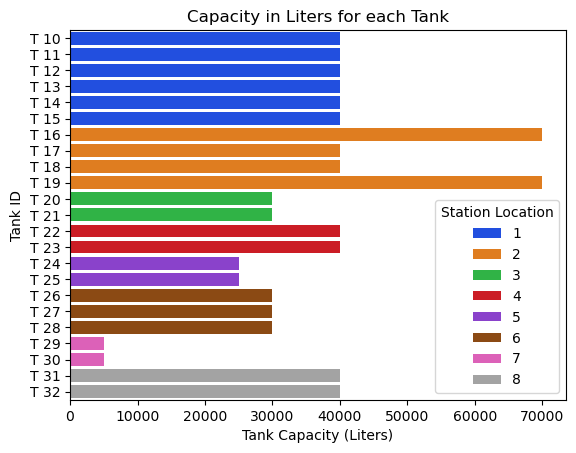

In [14]:
axes = sns.barplot(tanksloc_df, x = 'tank_capa', y = 'tank_id', hue = 'station_location', palette = 'bright')
axes.set(xlabel = 'Tank Capacity (Liters)', ylabel = 'Tank ID', title = 'Capacity in Liters for each Tank')
axes.legend(title = 'Station Location')
''

## 3.Number of Tanks in each Station with capacity

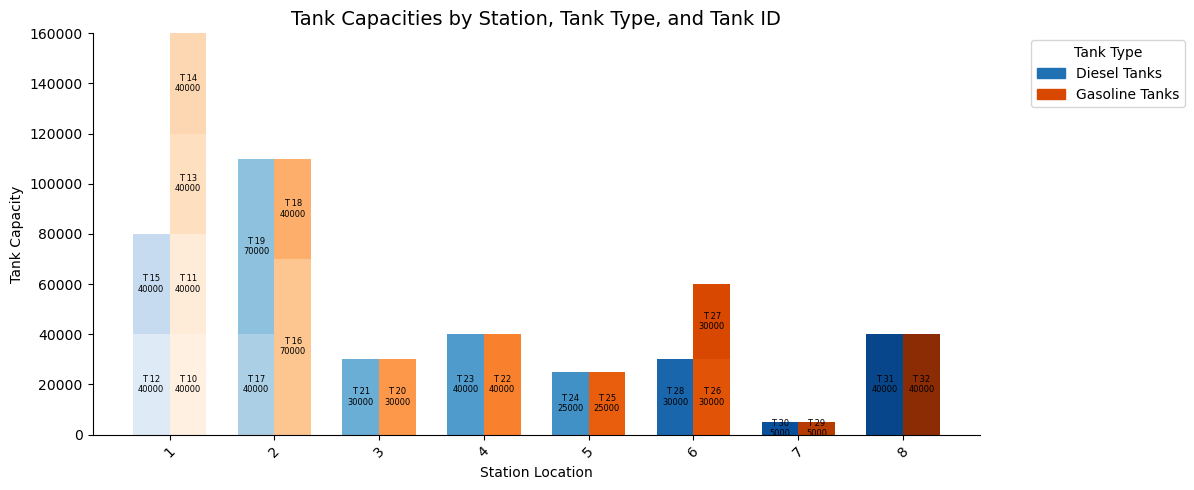

In [15]:
import matplotlib.pyplot as plt
tank_summary = (
    tanksloc_df
    .groupby(['station_location', 'tank_type2', 'tank_id'], as_index=False)['tank_capa']
    .sum()
)

pivot_df = tank_summary.pivot_table(
    index=['station_location', 'tank_type2'],
    columns='tank_id',
    values='tank_capa',
    fill_value=0
)

tank_types = pivot_df.index.get_level_values('tank_type2').unique()
station_locs = pivot_df.index.get_level_values('station_location').unique()

fig, ax = plt.subplots(figsize=(10,5))
bar_width = 0.35
x = np.arange(len(station_locs))

diesel_colors = sns.color_palette("Blues", n_colors=len(pivot_df.columns))
gasoline_colors = sns.color_palette("Oranges", n_colors=len(pivot_df.columns))

for i, ttype in enumerate(tank_types):
    sub = pivot_df.loc[pivot_df.index.get_level_values('tank_type2') == ttype]
    sub = sub.reindex(station_locs, level=0)

    bottom = np.zeros(len(station_locs))
    colors = diesel_colors if "diesel" in ttype.lower() else gasoline_colors

    for color, tank_id in zip(colors, sub.columns):
        bars = ax.bar(
            x + i*bar_width,
            sub[tank_id],
            bar_width,
            bottom=bottom,
            color=color,
            edgecolor='none'
        )

        # Label each stacked segment with tank_id and capacity
        for j, bar in enumerate(bars):
            height = bar.get_height()
            if height > 0:
                ax.text(
                    bar.get_x() + bar.get_width()/2,
                    bar.get_y() + height/2,
                    f"{tank_id}\n{int(height)}",
                    ha='center', va='center',
                    fontsize=6, color='black'
                )
        bottom += sub[tank_id]

ax.set_title("Tank Capacities by Station, Tank Type, and Tank ID", fontsize=14)
ax.set_xlabel("Station Location")
ax.set_ylabel("Tank Capacity")
ax.set_xticks(x + bar_width/2)
ax.set_xticklabels(station_locs, rotation=45)
sns.despine()
plt.tight_layout()
#ax.legend(title = 'Tank Type', )

legend_patches = [
    Patch(color=sns.color_palette("Blues", 3)[2], label="Diesel Tanks"),
    Patch(color=sns.color_palette("Oranges", 3)[2], label="Gasoline Tanks")
]
ax.legend(handles=legend_patches, title="Tank Type", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

plt.show()

## 4. Invoices per Station

<Axes: title={'center': 'Count of Invoices by each Station'}, xlabel='Station Number', ylabel='Count of Invoices'>

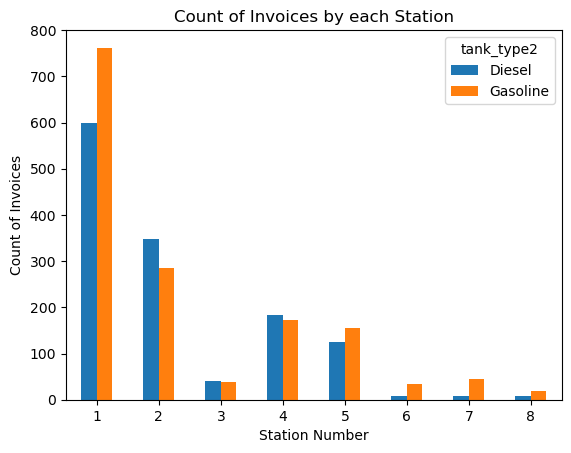

In [16]:
invoices_df2.pivot_table(index = 'station_location', columns = 'tank_type2', values = 'invoice_id', aggfunc = 'count').plot(kind = 'bar',
                                                                                                                           xlabel = 'Station Number',
                                                                                                                           ylabel = 'Count of Invoices',
                                                                                                                            title = 'Count of Invoices by each Station',
                                                                                                                            rot = 0
                                                                                                                           )

## 5. Order Frequency by Station

In [17]:
invoice_freq = invoices_df2.groupby(['station_location','tank_type2','invoice_date', 'Weekday'])['invoice_id'].count().reset_index()
invoice_freq['lead_day'] = invoice_freq.groupby(['station_location','tank_type2'])['invoice_date'].diff().dt.days
#invoice_freq.groupby(['station_location','tank_type2'])['lead_day'].mean().sort_values().reset_index()
invoice_freq.pivot_table(index = 'station_location', columns = 'tank_type2', values = 'lead_day', aggfunc = 'mean').sort_values(by = 'Gasoline')

tank_type2,Diesel,Gasoline
station_location,,
1,2.13,1.78
4,5.24,5.56
2,4.24,5.81
5,7.65,6.20
7,94.57,21.37
3,19.60,23.39
6,140.83,31.62
8,97.00,49.28


''

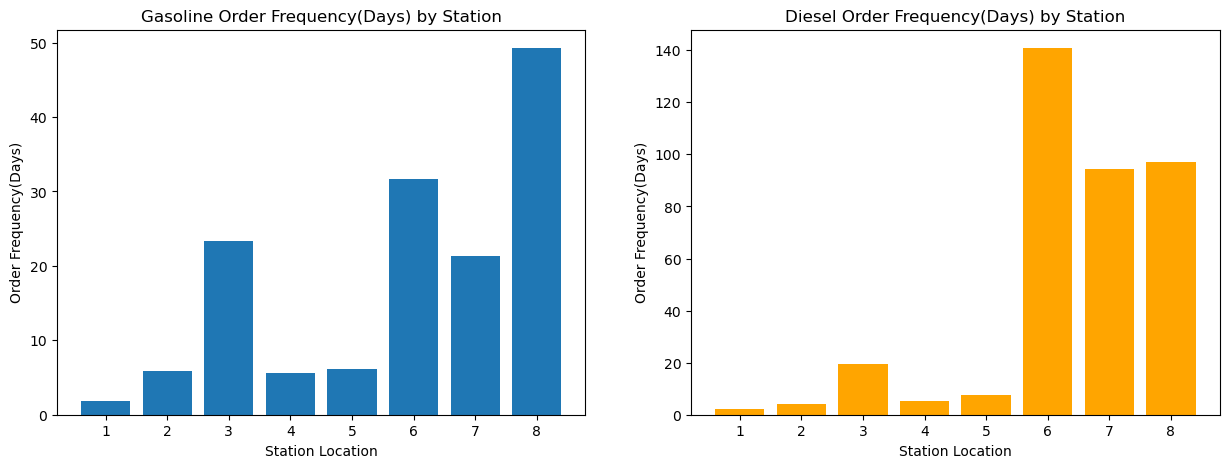

In [18]:
invoice_freq_g = invoice_freq.query("tank_type2 == 'Gasoline'").groupby('station_location')['lead_day'].mean().reset_index()
invoice_freq_d = invoice_freq.query("tank_type2 == 'Diesel'").groupby('station_location')['lead_day'].mean().reset_index()

fig, ax = plt.subplots(1,2, figsize=(15,5))

#add bar chart that shows gasoline order frequency by station
ax[0].bar(invoice_freq_g.station_location, invoice_freq_g.lead_day)
ax[0].set(xlabel = 'Station Location', ylabel = 'Order Frequency(Days)', title = 'Gasoline Order Frequency(Days) by Station')

#add bar chart that shows diesel order frequency by station 
ax[1].bar(invoice_freq_d.station_location, invoice_freq_d.lead_day, color = 'orange')
ax[1].set(xlabel = 'Station Location', ylabel = 'Order Frequency(Days)', title = 'Diesel Order Frequency(Days) by Station')

;

## Invoices per Day of Week

<Axes: title={'center': 'Number of Invoices by day of Week'}, xlabel='Day of Week', ylabel='Count of Invoices'>

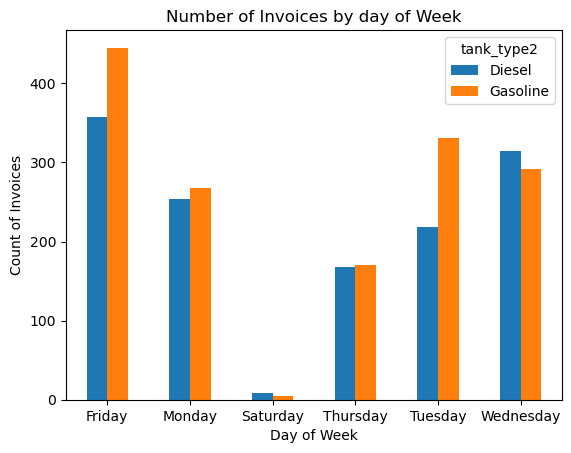

In [19]:
invoices_df2.pivot_table(index = 'Weekday', columns = 'tank_type2', values = 'invoice_id', aggfunc = 'count').plot(kind = 'bar',
                                                                                                                           xlabel = 'Day of Week',
                                                                                                                           ylabel = 'Count of Invoices',
                                                                                                                            title = 'Number of Invoices by day of Week',
                                                                                                                    rot = 0
                                                                                                                           )

# ------------------------------------------

# **Fuel Level/Inventory Patterns by gas stations**

## `2A` *How do fuel levels in each station’s tanks change over time?*

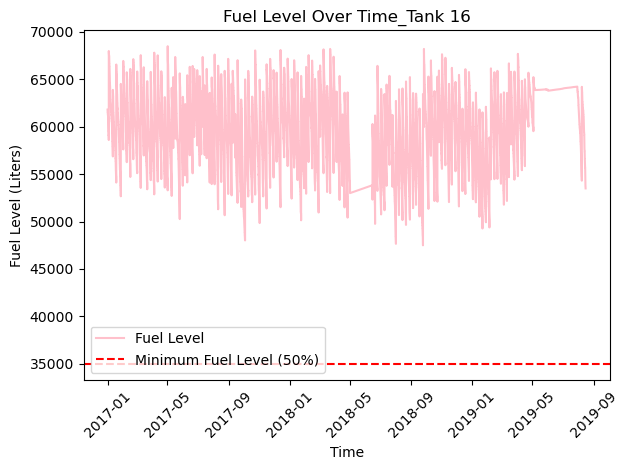

In [20]:
# focus on Tank 16, tank type is U_regular, gas location is 2

tank16_df = fueltank_df[fueltank_df['tank_id'] == 'T 16']
tank16_df.shape
tank16_df.head()
tank_capacity = tank16_df['tank_capa'].iloc[0]
min_val = tank16_df['fuel_level'].min() * 1.05 #Set the Y axis lower limit slightly below the minimum value

sns.lineplot(
    data=tank16_df,
    x='timestamp',
    y='fuel_level',
    color='pink', 
    linewidth=1.5,
    label='Fuel Level')

plt.axhline(
    y= tank_capacity * 0.5, #set 50% of tank capacity as min safety threshold
    color='red',
    linestyle='--',
    linewidth=1.5,
    label='Minimum Fuel Level (50%)'
)

plt.title('Fuel Level Over Time_Tank 16')
plt.xlabel('Time')
plt.ylabel('Fuel Level (Liters)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

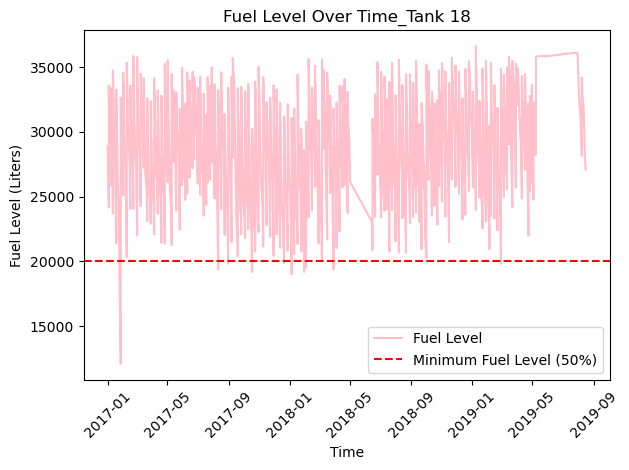

In [21]:
# focus on Tank 18, tank type is regular, gas location is 2

tank18_df = fueltank_df[fueltank_df['tank_id'] == 'T 18']
tank18_df.shape
tank18_df.head()
tank_capacity = tank18_df['tank_capa'].iloc[0]
min_val = tank18_df['fuel_level'].min() * 1.05

sns.lineplot(
    data=tank18_df,
    x='timestamp',
    y='fuel_level',
    color='pink', 
    linewidth=1.5,
    label='Fuel Level')

plt.axhline(
    y= tank_capacity * 0.5,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label='Minimum Fuel Level (50%)'
)

plt.title('Fuel Level Over Time_Tank 18')
plt.xlabel('Time')
plt.ylabel('Fuel Level (Liters)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

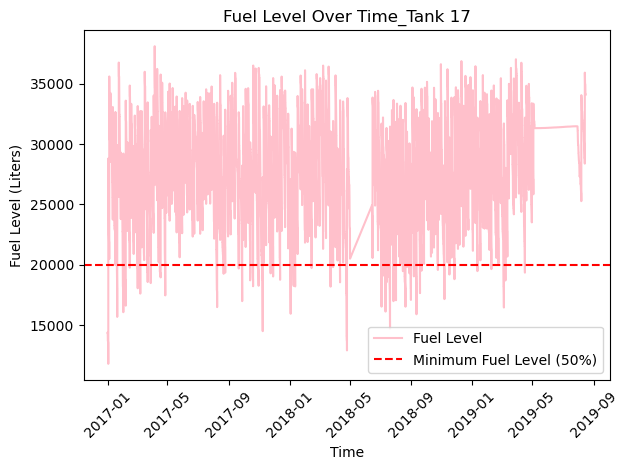

In [22]:
# focus on Tank 17, tank type is D_Diesel, gas location is 2

tank17_df = fueltank_df[fueltank_df['tank_id'] == 'T 17']
tank17_df.shape
tank17_df.head()
tank_capacity = tank17_df['tank_capa'].iloc[0]
min_val = tank17_df['fuel_level'].min() * 1.05

sns.lineplot(
    data=tank17_df,
    x='timestamp',
    y='fuel_level',
    color='pink', 
    linewidth=1.5,
    label='Fuel Level')

plt.axhline(
    y= tank_capacity * 0.5,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label='Minimum Fuel Level (50%)'
)

plt.title('Fuel Level Over Time_Tank 17')
plt.xlabel('Time')
plt.ylabel('Fuel Level (Liters)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


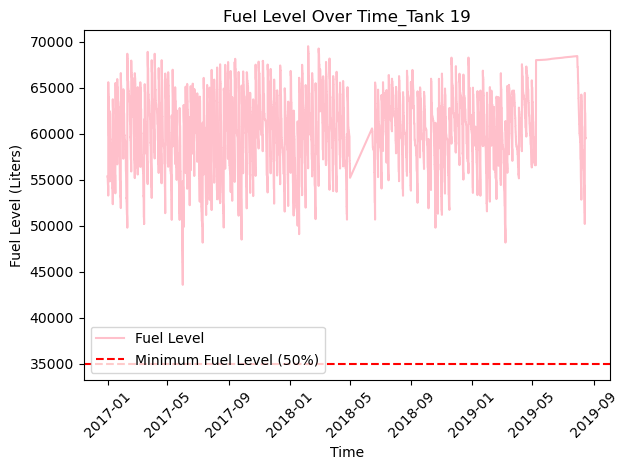

In [23]:
# focus on Tank 19
tank19_df = fueltank_df[fueltank_df['tank_id'] == 'T 19']
tank19_df.shape
tank19_df.head()
tank_capacity = tank19_df['tank_capa'].iloc[0]
min_val = tank19_df['fuel_level'].min() * 1.05

sns.lineplot(
    data=tank19_df,
    x='timestamp',
    y='fuel_level',
    color='pink', 
    linewidth=1.5,
    label='Fuel Level')

plt.axhline(
    y= tank_capacity * 0.5,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label='Minimum Fuel Level (50%)'
)

plt.title('Fuel Level Over Time_Tank 19')
plt.xlabel('Time')
plt.ylabel('Fuel Level (Liters)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

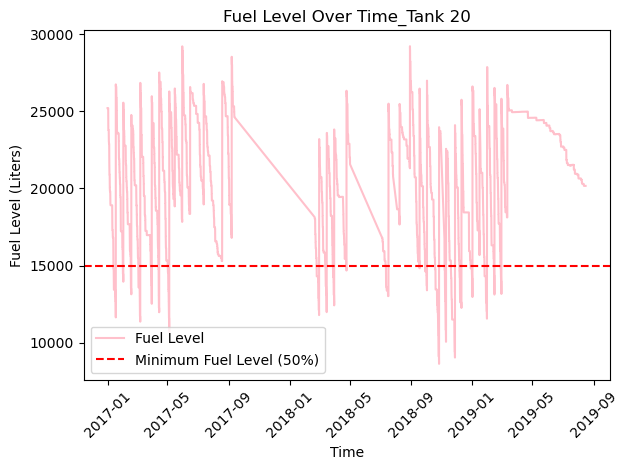

In [24]:
#station 3, tank 20_regular and 21_diesel
tank20_df = fueltank_df[fueltank_df['tank_id'] == 'T 20']
tank20_df.shape
tank20_df.head()
tank_capacity = tank20_df['tank_capa'].iloc[0]
min_val = tank20_df['fuel_level'].min() * 1.05

sns.lineplot(
    data=tank20_df,
    x='timestamp',
    y='fuel_level',
    color='pink', 
    linewidth=1.5,
    label='Fuel Level')

plt.axhline(
    y= tank_capacity * 0.5,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label='Minimum Fuel Level (50%)'
)

plt.title('Fuel Level Over Time_Tank 20')
plt.xlabel('Time')
plt.ylabel('Fuel Level (Liters)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

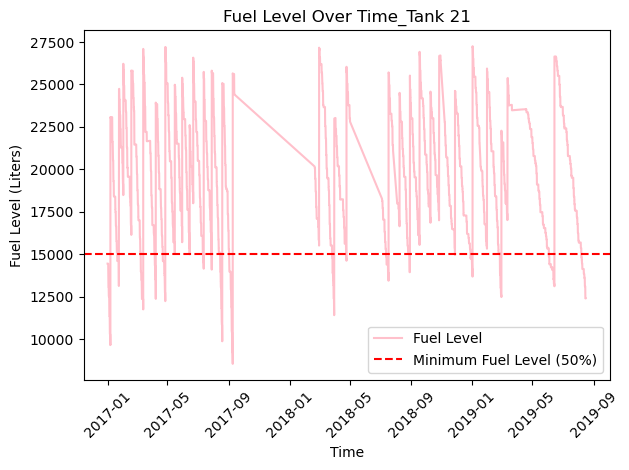

In [25]:
#station 3, tank 20_regular and 21_diesel
tank21_df = fueltank_df[fueltank_df['tank_id'] == 'T 21']
tank21_df.shape
tank21_df.head()
tank_capacity = tank21_df['tank_capa'].iloc[0]
min_val = tank21_df['fuel_level'].min() * 1.05

sns.lineplot(
    data=tank21_df,
    x='timestamp',
    y='fuel_level',
    color='pink', 
    linewidth=1.5,
    label='Fuel Level')

plt.axhline(
    y= tank_capacity * 0.5,
    color='red',
    linestyle='--',
    linewidth=1.5,
    label='Minimum Fuel Level (50%)'
)

plt.title('Fuel Level Over Time_Tank 21')
plt.xlabel('Time')
plt.ylabel('Fuel Level (Liters)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# `2C` *Calculate each location and each fuel type of total tank capacity*

In [26]:
# tanksloc_df
#sum tank capacity
capacity_1 = tanks_df.groupby(['station_location', 'tank_type1'])['tank_capa'].sum().reset_index()
capacity_1.rename(columns={'tank_capa': 'total_capacity'}, inplace=True)
capacity_1
# Find out the max discount rate for each gas station
def discount_per_liter(capacity):
    if capacity <= 15000:
        return 0
    elif capacity <= 25000:
        return 2
    elif capacity <= 40000:
        return 3
    else:
        return 4
capacity_1['discount_cents_per_liter'] = capacity_1['total_capacity'].apply(discount_per_liter)
#station_discount = capacity_1.groupby('station_location')['discount_cents_per_liter'].max().reset_index()
station_discount = capacity_1.groupby(['station_location','tank_type1'])['discount_cents_per_liter'].max().reset_index()
station_discount.rename(columns = {'discount_cents_per_liter': 'max_discount_cents'}, inplace = True)
station_discount.sort_values(by = 'max_discount_cents', ascending = False)

,station_location,tank_type1,max_discount_cents
0,1,D,4
2,1,U,4
3,2,D,4
4,2,U,4
12,6,U,4
1,1,P,3
15,8,D,3
11,6,D,3
8,4,U,3
7,4,D,3


/var/folders/nr/x6d82jnx1pn04_gdb8vr44sr0000gn/T/ipykernel_73119/860313348.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=station_discount, x='station_location', y='max_discount_cents',palette='muted')


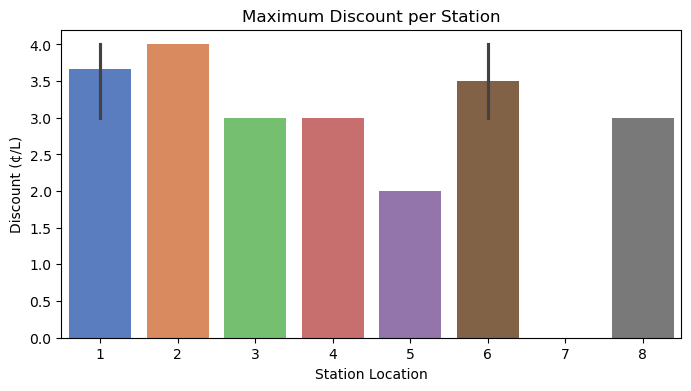

In [27]:
plt.figure(figsize=(8,4))
sns.barplot(data=station_discount, x='station_location', y='max_discount_cents',palette='muted')

plt.title('Maximum Discount per Station')
plt.xlabel('Station Location')
plt.ylabel('Discount (¢/L)')
plt.show()

# **Inventory replenishment patterns**

# `3A` *Replenishment frequency by station and fuel type*

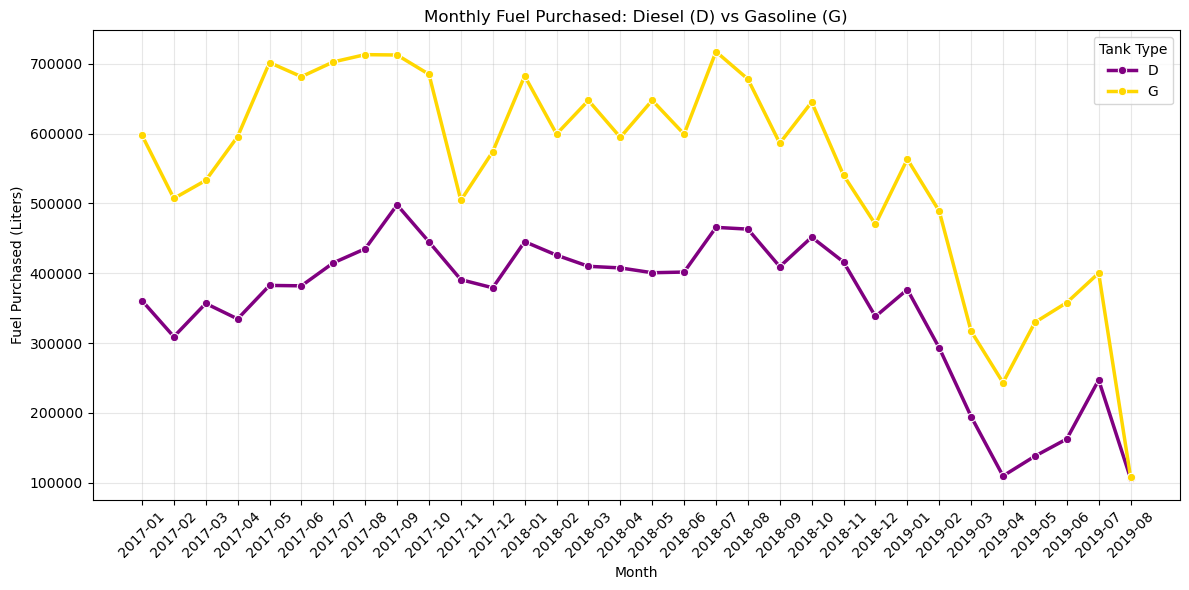

In [28]:
# Convert the date column to datetime format
#invoices_df2['invoice_date'] = pd.to_datetime(invoices_df2['invoice_date'])
invoices_df2['year_month'] = invoices_df2['invoice_date'].dt.to_period('M').astype(str)

# calculate the total purchased amount by fuel type and month
purchase_df = (invoices_df2.groupby(['year_month', 'tank_type1'])['purchased_amount'].sum().reset_index())

plt.figure(figsize=(12,6)) # compare the two different fuel types' purchased amount
sns.lineplot(data= purchase_df, x='year_month', y='purchased_amount', hue='tank_type1', palette={'D': 'purple', 'G': 'gold'}, linewidth=2.5, marker='o')

plt.title('Monthly Fuel Purchased: Diesel (D) vs Gasoline (G)')
plt.xlabel('Month')
plt.ylabel('Fuel Purchased (Liters)')
plt.xticks(rotation=45)
plt.legend(title='Tank Type', loc='upper right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#  `3B` *Are stations taking advantage of the maximum discount?*

In [29]:
invoices_df2

,index,invoice_date,invoice_id,station_location,purchased_cost,purchased_amount,tank_type1,tank_type2,Year,Month,Day,Day_dig,Weekday,price_per_liter,year_month
0,0,2017-01-02,10000.0,1,7570.82,6609.60,G,Gasoline,2017,1,2,0,Monday,1.15,2017-01
1,1,2017-01-02,10001.0,1,12491.85,9338.74,D,Diesel,2017,1,2,0,Monday,1.34,2017-01
2,3,2017-01-02,10002.0,2,17034.35,13377.82,D,Diesel,2017,1,2,0,Monday,1.27,2017-01
3,5,2017-01-02,10003.0,2,12616.77,9432.11,D,Diesel,2017,1,2,0,Monday,1.34,2017-01
4,6,2017-01-02,10004.0,4,11363.80,9139.20,D,Diesel,2017,1,2,0,Monday,1.24,2017-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2826,2868,2019-08-14,12826.0,2,14418.63,8182.96,D,Diesel,2019,8,14,2,Wednesday,1.76,2019-08
2827,2869,2019-08-14,12827.0,2,7570.82,4296.64,D,Diesel,2019,8,14,2,Wednesday,1.76,2019-08
2828,2870,2019-08-14,12828.0,4,8706.44,6352.42,G,Gasoline,2019,8,14,2,Wednesday,1.37,2019-08
2829,2871,2019-08-14,12829.0,4,13252.72,7521.26,D,Diesel,2019,8,14,2,Wednesday,1.76,2019-08


In [30]:
# create discount per liter column
def disc_per (x): 
    """
    returns the discount per liter amount for each invoice received in canadian dollars
    """
    if x <= 15000:
        return 0
    elif x <= 25000:
        return 0.02
    elif x <= 40000:
        return 0.03
    else:
        return 0.04

invoices_df2['disc_per_liter'] = invoices_df2['purchased_amount'].apply(disc_per)
invoices_df2.head(30)

,index,invoice_date,invoice_id,station_location,purchased_cost,purchased_amount,tank_type1,tank_type2,Year,Month,Day,Day_dig,Weekday,price_per_liter,year_month,disc_per_liter
0,0,2017-01-02,10000.0,1,7570.82,6609.60,G,Gasoline,2017,1,2,0,Monday,1.15,2017-01,0.00
1,1,2017-01-02,10001.0,1,12491.85,9338.74,D,Diesel,2017,1,2,0,Monday,1.34,2017-01,0.00
2,3,2017-01-02,10002.0,2,17034.35,13377.82,D,Diesel,2017,1,2,0,Monday,1.27,2017-01,0.00
3,5,2017-01-02,10003.0,2,12616.77,9432.11,D,Diesel,2017,1,2,0,Monday,1.34,2017-01,0.00
4,6,2017-01-02,10004.0,4,11363.80,9139.20,D,Diesel,2017,1,2,0,Monday,1.24,2017-01,0.00
5,7,2017-01-02,10005.0,5,9573.30,7156.86,D,Diesel,2017,1,2,0,Monday,1.34,2017-01,0.00
6,8,2017-01-03,10006.0,1,5670.54,4239.22,D,Diesel,2017,1,3,1,Tuesday,1.34,2017-01,0.00
7,9,2017-01-03,10007.0,1,7627.60,6659.18,G,Gasoline,2017,1,3,1,Tuesday,1.15,2017-01,0.00
8,10,2017-01-03,10008.0,1,32175.99,26704.96,G,Gasoline,2017,1,3,1,Tuesday,1.20,2017-01,0.03
9,11,2017-01-03,10009.0,2,9467.31,8265.31,G,Gasoline,2017,1,3,1,Tuesday,1.15,2017-01,0.00


In [31]:
# calculate total discount each invoice received
invoices_df2['disc_total'] = invoices_df2['purchased_amount'] * invoices_df2['disc_per_liter']
invoices_df2.head(3)

,index,invoice_date,invoice_id,station_location,purchased_cost,purchased_amount,tank_type1,tank_type2,Year,Month,Day,Day_dig,Weekday,price_per_liter,year_month,disc_per_liter,disc_total
0,0,2017-01-02,10000.0,1,7570.82,6609.60,G,Gasoline,2017,1,2,0,Monday,1.15,2017-01,0.0,0.0
1,1,2017-01-02,10001.0,1,12491.85,9338.74,D,Diesel,2017,1,2,0,Monday,1.34,2017-01,0.0,0.0
2,3,2017-01-02,10002.0,2,17034.35,13377.82,D,Diesel,2017,1,2,0,Monday,1.27,2017-01,0.0,0.0


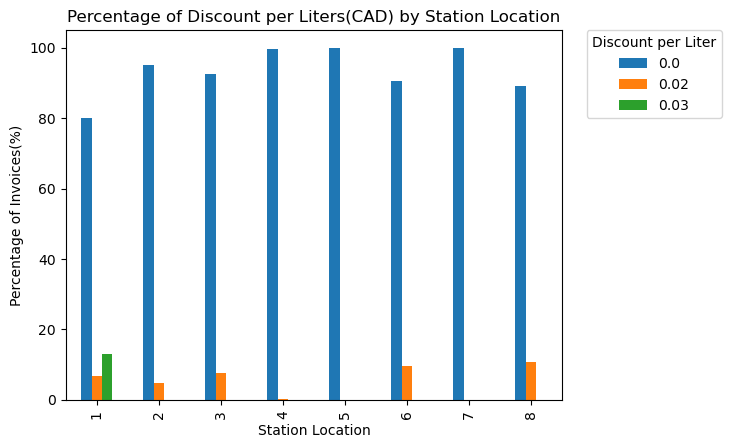

In [32]:
# 1. What % of all invoices received a discount for each station?
axes = pd.crosstab(invoices_df2['station_location'], invoices_df2['disc_per_liter'], normalize = 'index').mul(100).plot(kind = 'bar')
axes.set(xlabel = 'Station Location', ylabel = 'Percentage of Invoices(%)', title = 'Percentage of Discount per Liters(CAD) by Station Location')
axes.legend(title = 'Discount per Liter', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)

/var/folders/nr/x6d82jnx1pn04_gdb8vr44sr0000gn/T/ipykernel_73119/247981916.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


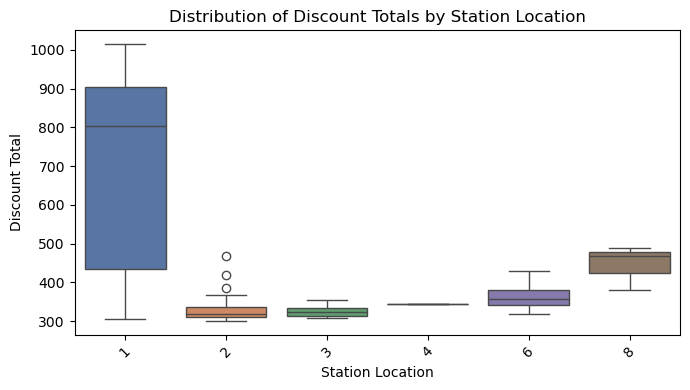

In [33]:
# 2. What is the average discount amount each station received per invoice for invoices that did receive discount?
plt.figure(figsize=(7,4))
sns.boxplot(
    data=invoices_df2.query('disc_total > 0'),
    x='station_location',
    y='disc_total',
    palette='deep'
)

plt.title('Distribution of Discount Totals by Station Location')
plt.xlabel('Station Location')
plt.ylabel('Discount Total')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

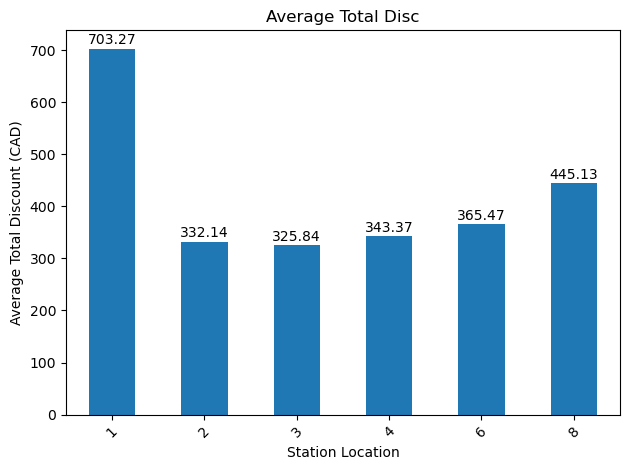

In [34]:
#2. What is the average discount amount each station received per invoice for invoices that did receive discount?
avg_disc = invoices_df2.query("disc_per_liter > 0").groupby('station_location')['disc_total'].mean()

# Plot the bar chart
ax = avg_disc.plot(kind='bar')

# Add labels
plt.title('Average Total Disc')
plt.xlabel('Station Location')
plt.ylabel('Average Total Discount (CAD)')
plt.xticks(rotation=45)

# Show data labels on each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge', padding=1)

plt.tight_layout()
plt.show()

In [35]:
# 3. What is the maximum discount that each station can receive?
invoice_max = tanksloc_df.groupby(['station_location', 'tank_type2'])['tank_capa'].agg(['sum', 'count']).reset_index()
invoice_max
invoice_max['disc_per_liter']=invoice_max['sum'].apply(disc_per)
invoice_max['disc_max'] = invoice_max['disc_per_liter'] * invoice_max['sum']
invoice_max

# 3. What is the maximum discount that each station can receive?
station_capa_df = tanksloc_df.groupby(['station_location','tank_type2'])['tank_capa'].agg(total_capa = ('sum'), tank_cnt = ('count')).reset_index()
station_capa_df['disc_per_liter'] = station_capa_df['total_capa'].apply(disc_per)
station_capa_df['min_level'] = station_capa_df['total_capa'] * 0.5
station_capa_df['disc_max'] = station_capa_df['disc_per_liter'] * station_capa_df['total_capa']
station_capa_df['disc_per_liter2'] = station_capa_df['min_level'].apply(disc_per)
station_capa_df['disc_min_max'] = station_capa_df['disc_per_liter'] * station_capa_df['min_level']
station_capa_df

,station_location,tank_type2,total_capa,tank_cnt,disc_per_liter,min_level,disc_max,disc_per_liter2,disc_min_max
0,1,Diesel,80000,2,0.04,40000.0,3200.0,0.03,1600.0
1,1,Gasoline,160000,4,0.04,80000.0,6400.0,0.04,3200.0
2,2,Diesel,110000,2,0.04,55000.0,4400.0,0.04,2200.0
3,2,Gasoline,110000,2,0.04,55000.0,4400.0,0.04,2200.0
4,3,Diesel,30000,1,0.03,15000.0,900.0,0.00,450.0
5,3,Gasoline,30000,1,0.03,15000.0,900.0,0.00,450.0
6,4,Diesel,40000,1,0.03,20000.0,1200.0,0.02,600.0
7,4,Gasoline,40000,1,0.03,20000.0,1200.0,0.02,600.0
8,5,Diesel,25000,1,0.02,12500.0,500.0,0.00,250.0
9,5,Gasoline,25000,1,0.02,12500.0,500.0,0.00,250.0


In [36]:
avg_disc = invoices_df2.groupby(['station_location','tank_type2'])['disc_total'].mean().sort_index()

# `3C` When prices fluctuate, do the stations reduce or increase the frequency and quantity of the replenishment?

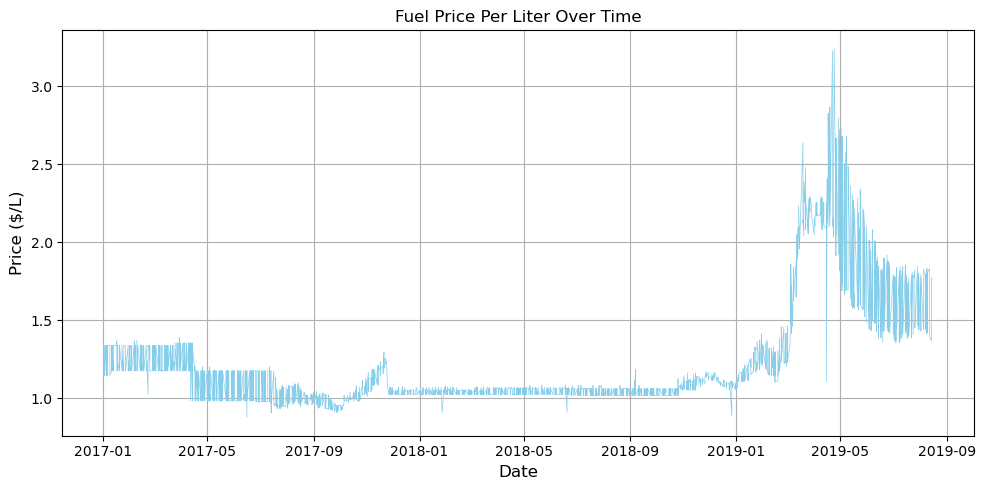

In [37]:
# Plot the trend of fuel price per liter over time
plt.figure(figsize=(10, 5))  
plt.plot(invoices_df2['invoice_date'], invoices_df2['price_per_liter'], color = 'skyblue', linewidth=0.5)

plt.title('Fuel Price Per Liter Over Time', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price ($/L)', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

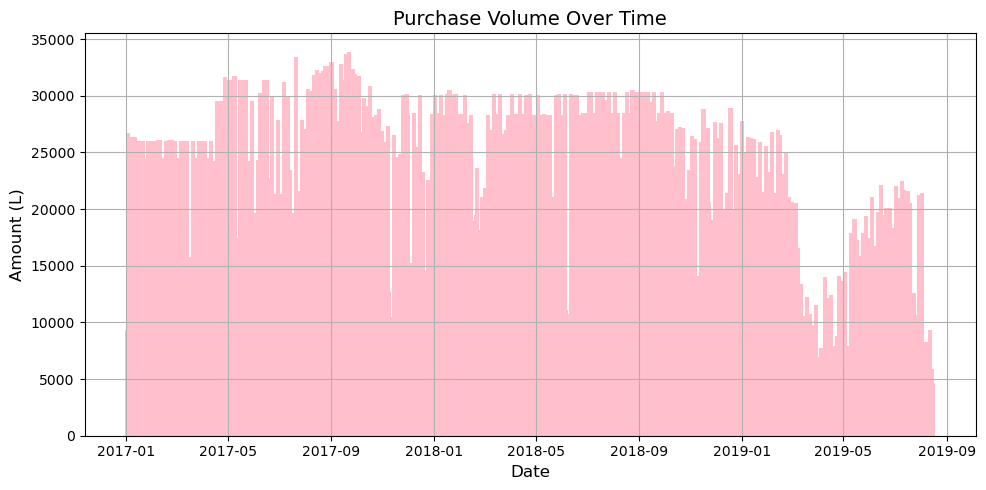

In [38]:
# Bar plot showing purchased amount by date for a specific station
# Take gas_station1 as an example
plt.figure(figsize=(10, 5))  
plt.bar(invoices_df2.loc[invoices_df2['station_location'] == 1, 'invoice_date'],
        invoices_df2.loc[invoices_df2['station_location'] == 1, 'purchased_amount'],
        color = 'pink', 
        width = 5)

plt.title('Purchase Volume Over Time', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Amount (L)', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

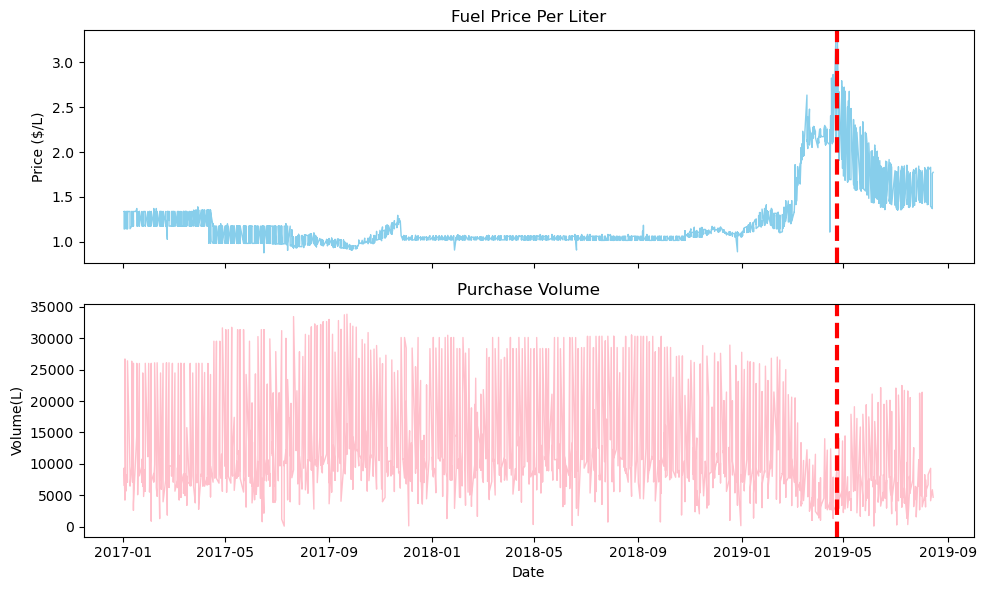

In [39]:
# Plot two aligned subplots: fuel price trend (top) and purchase volume (bottom)
# This is for gas_station1, and then analyze each gas station

fig, (ax1, ax2) = plt.subplots(2,1, figsize=(10,6), sharex=True)
ax1.plot(invoices_df2['invoice_date'], invoices_df2['price_per_liter'], color='skyblue', linewidth=1)
ax1.set_ylabel('Price ($/L)')
ax1.set_title('Fuel Price Per Liter')


ax2.plot(invoices_df2.loc[invoices_df2['station_location'] == 1, 'invoice_date'],
        invoices_df2.loc[invoices_df2['station_location'] == 1, 'purchased_amount'],
        color = 'pink', 
        linewidth = 1)
ax2.set_xlabel('Date')
ax2.set_ylabel('Volume(L)')
ax2.set_title('Purchase Volume')

# Highlight the date of the highest price with a vertical red line
min_price_day = invoices_df2.loc[invoices_df2['price_per_liter'].idxmax(), 'invoice_date']
ax1.axvline(x=min_price_day, color='red', linestyle='--', linewidth=3)
ax2.axvline(x=min_price_day, color='red', linestyle='--', linewidth=3)

plt.tight_layout()
plt.show()

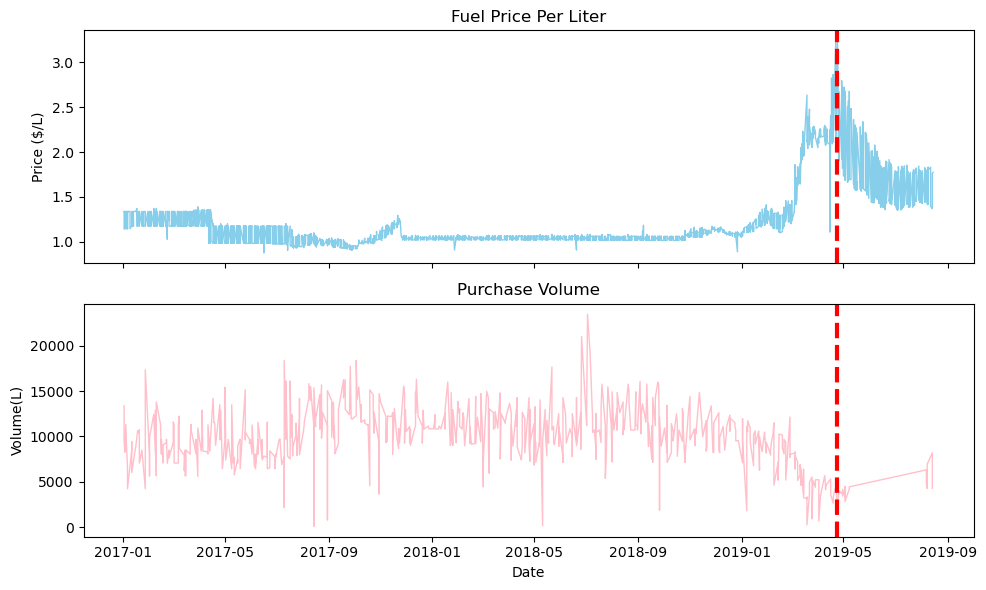

In [40]:
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(10,6), sharex=True)
ax1.plot(invoices_df2['invoice_date'], invoices_df2['price_per_liter'], color='skyblue', linewidth=1)
ax1.set_ylabel('Price ($/L)')
ax1.set_title('Fuel Price Per Liter')


ax2.plot(invoices_df2.loc[invoices_df2['station_location'] == 2, 'invoice_date'],
        invoices_df2.loc[invoices_df2['station_location'] == 2, 'purchased_amount'],
        color = 'pink', 
        linewidth = 1)
ax2.set_xlabel('Date')
ax2.set_ylabel('Volume(L)')
ax2.set_title('Purchase Volume')

min_price_day = invoices_df2.loc[invoices_df2['price_per_liter'].idxmax(), 'invoice_date']
ax1.axvline(x=min_price_day, color='red', linestyle='--', linewidth=3)
ax2.axvline(x=min_price_day, color='red', linestyle='--', linewidth=3)

plt.tight_layout()
plt.show()

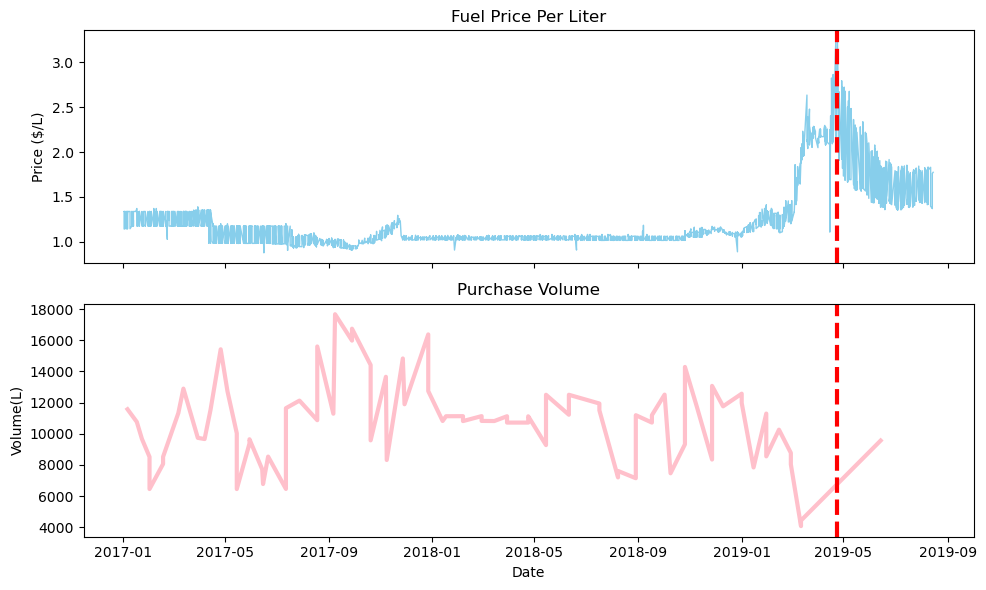

In [41]:
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(10,6), sharex=True)
ax1.plot(invoices_df2['invoice_date'], invoices_df2['price_per_liter'], color='skyblue', linewidth=1)
ax1.set_ylabel('Price ($/L)')
ax1.set_title('Fuel Price Per Liter')


ax2.plot(invoices_df2.loc[invoices_df2['station_location'] == 3, 'invoice_date'],
        invoices_df2.loc[invoices_df2['station_location'] == 3, 'purchased_amount'],
        color = 'pink', 
        linewidth = 3)
ax2.set_xlabel('Date')
ax2.set_ylabel('Volume(L)')
ax2.set_title('Purchase Volume')

min_price_day = invoices_df2.loc[invoices_df2['price_per_liter'].idxmax(), 'invoice_date']
ax1.axvline(x=min_price_day, color='red', linestyle='--', linewidth=3)
ax2.axvline(x=min_price_day, color='red', linestyle='--', linewidth=3)

plt.tight_layout()
plt.show()

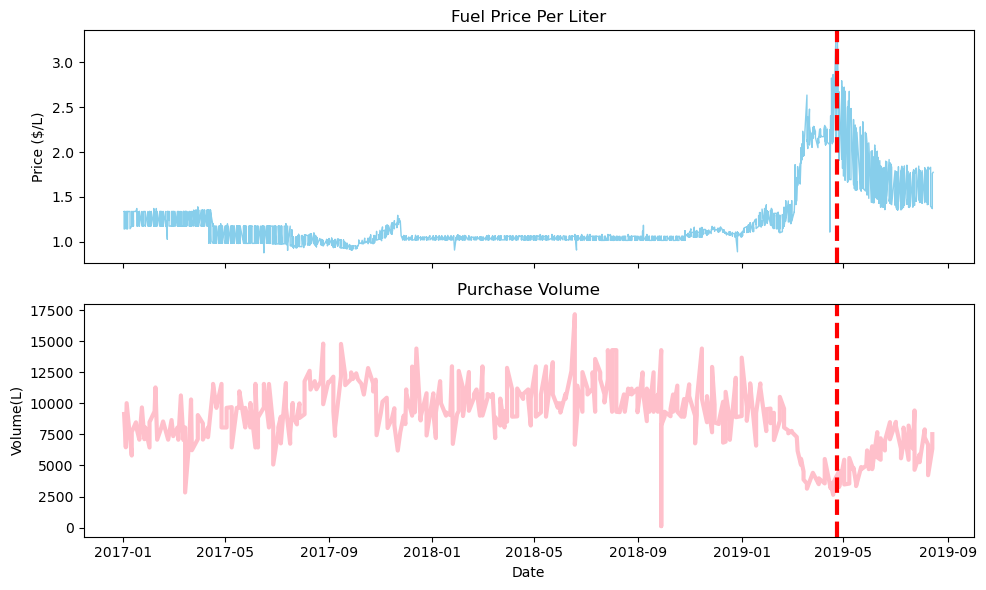

In [42]:
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(10,6), sharex=True)
ax1.plot(invoices_df2['invoice_date'], invoices_df2['price_per_liter'], color='skyblue', linewidth=1)
ax1.set_ylabel('Price ($/L)')
ax1.set_title('Fuel Price Per Liter')


ax2.plot(invoices_df2.loc[invoices_df2['station_location'] == 4, 'invoice_date'],
        invoices_df2.loc[invoices_df2['station_location'] == 4, 'purchased_amount'],
        color = 'pink', 
        linewidth = 3)
ax2.set_xlabel('Date')
ax2.set_ylabel('Volume(L)')
ax2.set_title('Purchase Volume')

min_price_day = invoices_df2.loc[invoices_df2['price_per_liter'].idxmax(), 'invoice_date']
ax1.axvline(x=min_price_day, color='red', linestyle='--', linewidth=3)
ax2.axvline(x=min_price_day, color='red', linestyle='--', linewidth=3)

plt.tight_layout()
plt.show()

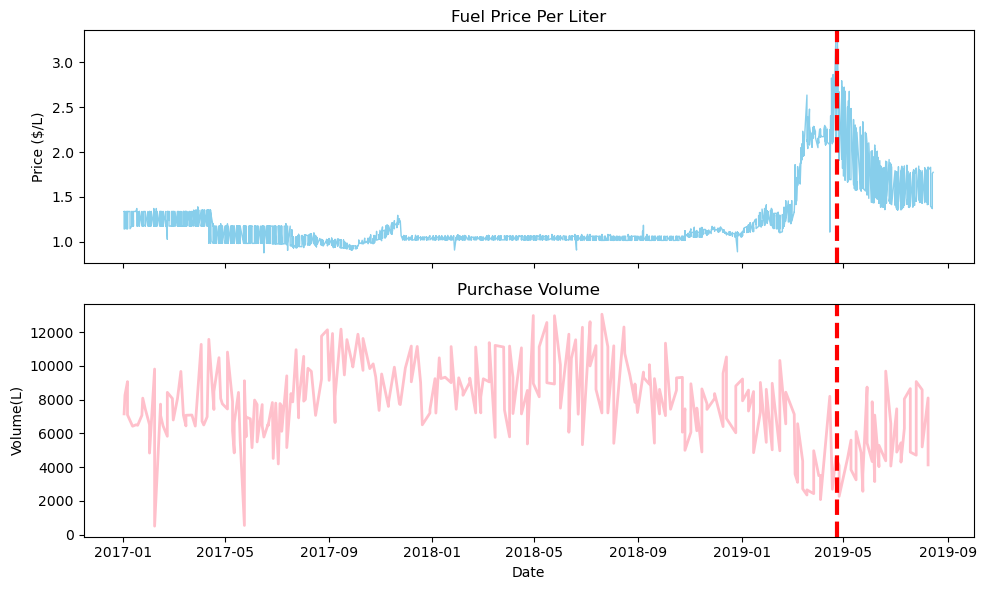

In [43]:
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(10,6), sharex=True)
ax1.plot(invoices_df2['invoice_date'], invoices_df2['price_per_liter'], color='skyblue', linewidth=1)
ax1.set_ylabel('Price ($/L)')
ax1.set_title('Fuel Price Per Liter')


ax2.plot(invoices_df2.loc[invoices_df2['station_location'] == 5, 'invoice_date'],
        invoices_df2.loc[invoices_df2['station_location'] == 5, 'purchased_amount'],
        color = 'pink', 
        linewidth = 2)
ax2.set_xlabel('Date')
ax2.set_ylabel('Volume(L)')
ax2.set_title('Purchase Volume')

min_price_day = invoices_df2.loc[invoices_df2['price_per_liter'].idxmax(), 'invoice_date']
ax1.axvline(x=min_price_day, color='red', linestyle='--', linewidth=3)
ax2.axvline(x=min_price_day, color='red', linestyle='--', linewidth=3)

plt.tight_layout()
plt.show()

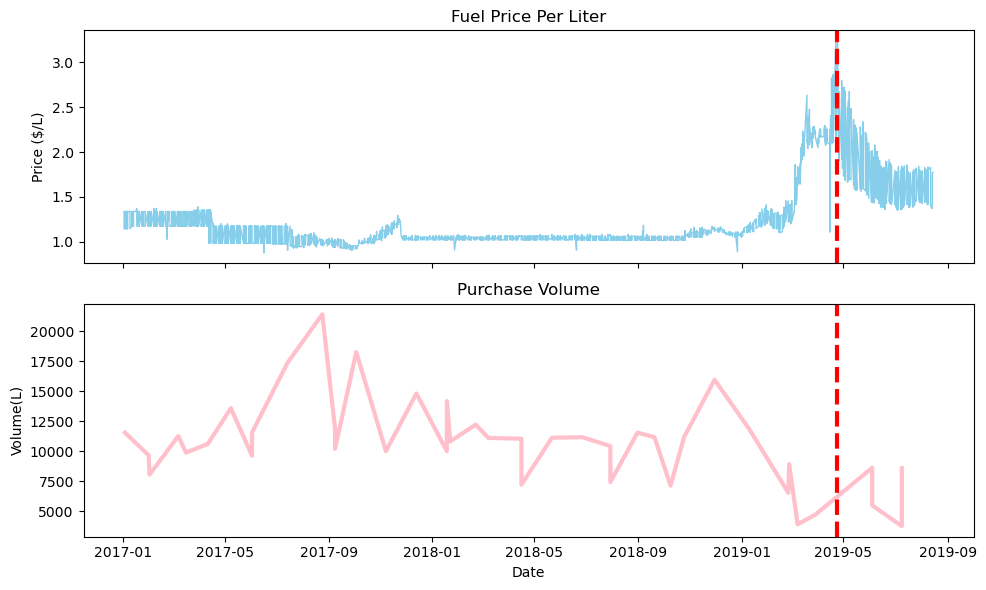

In [44]:
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(10,6), sharex=True)
ax1.plot(invoices_df2['invoice_date'], invoices_df2['price_per_liter'], color='skyblue', linewidth=1)
ax1.set_ylabel('Price ($/L)')
ax1.set_title('Fuel Price Per Liter')


ax2.plot(invoices_df2.loc[invoices_df2['station_location'] == 6, 'invoice_date'],
        invoices_df2.loc[invoices_df2['station_location'] == 6, 'purchased_amount'],
        color = 'pink', 
        linewidth = 3)
ax2.set_xlabel('Date')
ax2.set_ylabel('Volume(L)')
ax2.set_title('Purchase Volume')

min_price_day = invoices_df2.loc[invoices_df2['price_per_liter'].idxmax(), 'invoice_date']
ax1.axvline(x=min_price_day, color='red', linestyle='--', linewidth=3)
ax2.axvline(x=min_price_day, color='red', linestyle='--', linewidth=3)


plt.tight_layout()
plt.show()

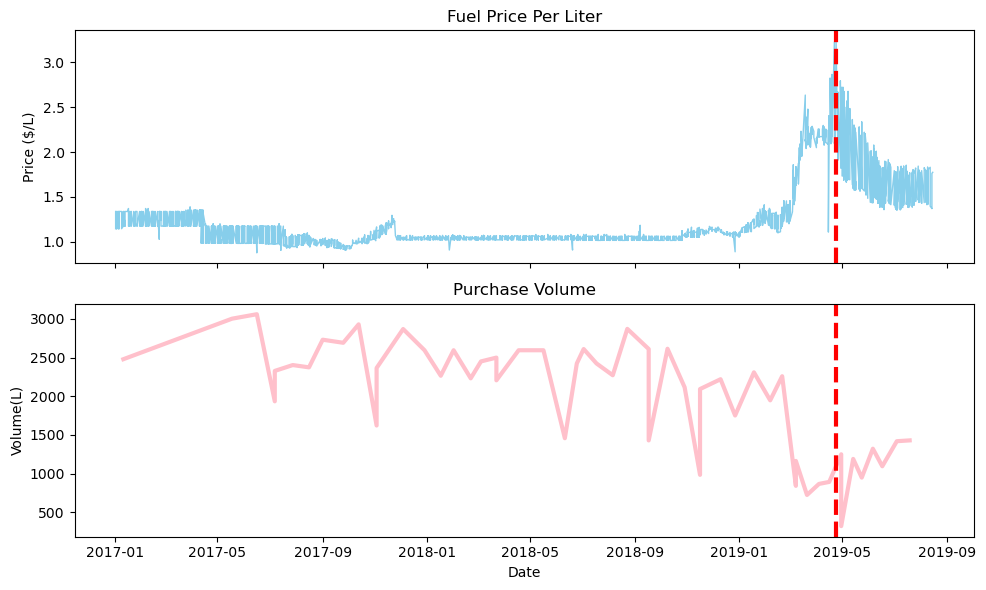

In [45]:
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(10,6), sharex=True)
ax1.plot(invoices_df2['invoice_date'], invoices_df2['price_per_liter'], color='skyblue', linewidth=1)
ax1.set_ylabel('Price ($/L)')
ax1.set_title('Fuel Price Per Liter')


ax2.plot(invoices_df2.loc[invoices_df2['station_location'] == 7, 'invoice_date'],
        invoices_df2.loc[invoices_df2['station_location'] == 7, 'purchased_amount'],
        color = 'pink', 
        linewidth = 3)
ax2.set_xlabel('Date')
ax2.set_ylabel('Volume(L)')
ax2.set_title('Purchase Volume')

min_price_day = invoices_df2.loc[invoices_df2['price_per_liter'].idxmax(), 'invoice_date']
ax1.axvline(x=min_price_day, color='red', linestyle='--', linewidth=3)
ax2.axvline(x=min_price_day, color='red', linestyle='--', linewidth=3)

plt.tight_layout()
plt.show()

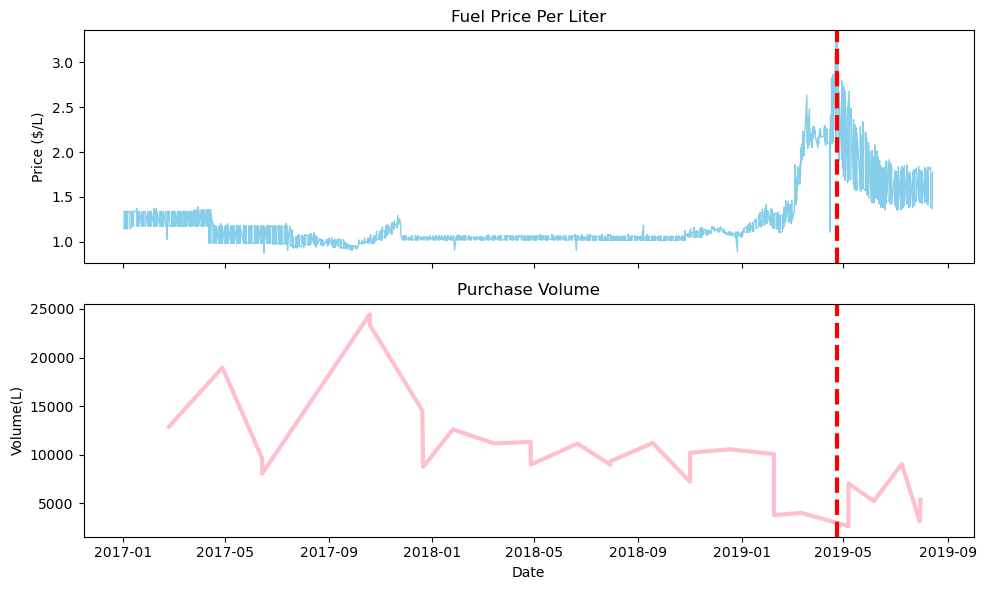

In [46]:
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(10,6), sharex=True)
ax1.plot(invoices_df2['invoice_date'], invoices_df2['price_per_liter'], color='skyblue', linewidth=1)
ax1.set_ylabel('Price ($/L)')
ax1.set_title('Fuel Price Per Liter')

ax2.plot(invoices_df2.loc[invoices_df2['station_location'] == 8, 'invoice_date'],
        invoices_df2.loc[invoices_df2['station_location'] == 8, 'purchased_amount'],
        color = 'pink', 
        linewidth = 3)
ax2.set_xlabel('Date')
ax2.set_ylabel('Volume(L)')
ax2.set_title('Purchase Volume')

min_price_day = invoices_df2.loc[invoices_df2['price_per_liter'].idxmax(), 'invoice_date']
ax1.axvline(x=min_price_day, color='red', linestyle='--', linewidth=3)
ax2.axvline(x=min_price_day, color='red', linestyle='--', linewidth=3)

plt.tight_layout()
plt.show()

In [47]:
Frequency = invoices_df2.pivot_table(index = ['Year','station_location'],
                                      values = 'invoice_id',
                                      columns = 'Month',
                                      aggfunc = 'count')
Frequency['avg_times'] = Frequency.mean(axis = 1)
Frequency

Month                     1     2     3     4     5     6     7     8     9  \
Year station_location                                                         
2017 1                 46.0  41.0  47.0  40.0  45.0  55.0  50.0  41.0  44.0   
     2                 23.0  20.0  24.0  20.0  27.0  27.0  25.0  24.0  20.0   
     3                  3.0   4.0   3.0   3.0   5.0   3.0   3.0   2.0   4.0   
     4                 11.0   9.0  12.0  10.0  11.0  10.0  14.0  10.0  12.0   
     5                 10.0  10.0   8.0  10.0  13.0  12.0  11.0   9.0   9.0   
     6                  2.0   1.0   2.0   1.0   1.0   2.0   1.0   1.0   2.0   
     7                  1.0   NaN   NaN   NaN   1.0   1.0   3.0   1.0   2.0   
     8                  NaN   1.0   NaN   1.0   NaN   2.0   NaN   NaN   NaN   
2018 1                 47.0  45.0  43.0  40.0  41.0  45.0  45.0  42.0  38.0   
     2                 23.0  20.0  22.0  22.0  27.0  18.0  22.0  23.0  22.0   
     3                  2.0   4.0   3.0   2.0   2.0   2.0   2.0   4.0   2.0   
     4                 12.0  10.0  14.0  10.0  10.0  11.0  12.0  14.0  13.0   
     5                  8.0   9.0   7.0  10.0   6.0   9.0   8.0   9.0   8.0   
     6                  3.0   1.0   1.0   2.0   1.0   1.0   2.0   1.0   1.0   
     7                  1.0   2.0   3.0   1.0   1.0   2.0   2.0   2.0   2.0   
     8                  1.0   NaN   1.0   2.0   NaN   1.0   2.0   NaN   1.0   
2019 1                 41.0  33.0  40.0  40.0  45.0  43.0  57.0  17.0   NaN   
     2                 23.0  22.0  24.0  21.0   5.0   NaN   NaN   6.0   NaN   
     3                  5.0   3.0   2.0   NaN   NaN   1.0   NaN   NaN   NaN   
     4                 12.0  10.0  11.0  10.0  13.0  10.0  13.0   6.0   NaN   
     5                 10.0   6.0  10.0   8.0  10.0  10.0  10.0   4.0   NaN   
     6                  1.0   2.0   2.0   NaN   NaN   2.0   3.0   NaN   NaN   
     7                  1.0   2.0   3.0   4.0   2.0   2.0   2.0   NaN   NaN   
     8                  NaN   2.0   1.0   NaN   2.0   1.0   3.0   NaN   NaN   

Month                    10    11    12  avg_times  
Year station_location                               
2017 1                 41.0  38.0  41.0      44.08  
     2                 23.0  19.0  18.0      22.50  
     3                  2.0   4.0   2.0       3.17  
     4                  9.0  11.0  10.0      10.75  
     5                  7.0   7.0   7.0       9.42  
     6                  1.0   1.0   1.0       1.33  
     7                  1.0   2.0   2.0       1.56  
     8                  2.0   NaN   2.0       1.60  
2018 1                 46.0  41.0  43.0      43.00  
     2                 24.0  22.0  16.0      21.75  
     3                  4.0   3.0   1.0       2.58  
     4                 14.0  12.0  10.0      11.83  
     5                  9.0  10.0   6.0       8.25  
     6                  2.0   1.0   NaN       1.45  
     7                  2.0   2.0   2.0       1.83  
     8                  NaN   2.0   1.0       1.38  
2019 1                  NaN   NaN   NaN      39.50  
     2                  NaN   NaN   NaN      16.83  
     3                  NaN   NaN   NaN       2.75  
     4                  NaN   NaN   NaN      10.62  
     5                  NaN   NaN   NaN       8.50  
     6                  NaN   NaN   NaN       2.00  
     7                  NaN   NaN   NaN       2.29  
     8                  NaN   NaN   NaN       1.80

<Figure size 1000x600 with 0 Axes>

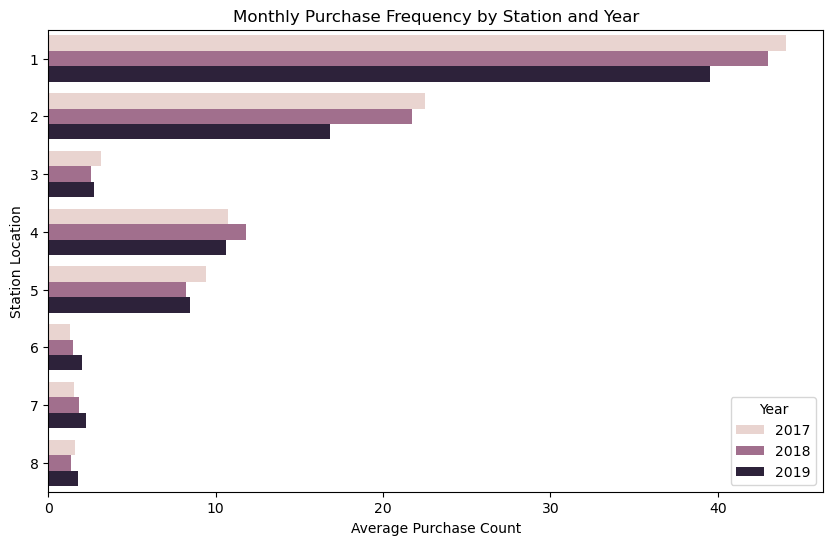

In [48]:
New_Frequency = Frequency.reset_index()

plt.figure(figsize=(10,6))

# Create a horizontal bar plot showing average purchase times for each station, grouped by year
plt.figure(figsize=(10,6))
sns.barplot(
    data=New_Frequency,
    x='avg_times',             
    y='station_location',     
    hue='Year',                
    orient='h',               
    errorbar=None)
    
plt.title('Monthly Purchase Frequency by Station and Year')
plt.xlabel('Average Purchase Count')
plt.ylabel('Station Location')
plt.legend(title='Year')
plt.show()

# **Better inventory policy**

## `4A` *Cost Saving Potential: if stations optimized their purchasing quantities, how much could they save annually?* 

''

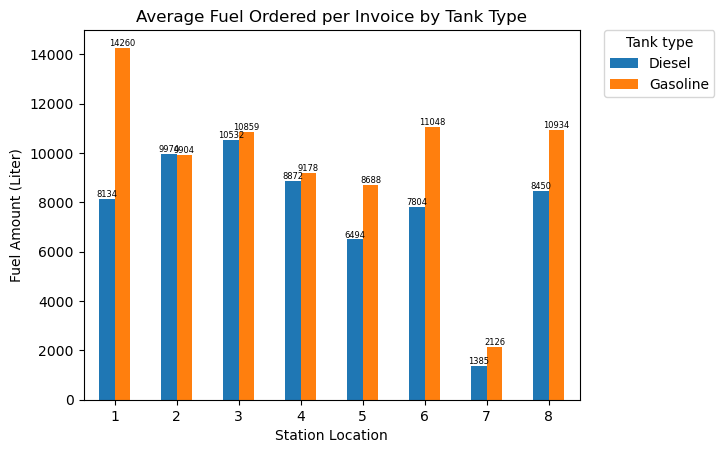

In [49]:
#1. Average Fuel Ordered per Invoice?
axes = invoices_df2.pivot_table(index = 'station_location', columns = 'tank_type2', values = 'purchased_amount', aggfunc = 'mean').plot(kind = 'bar',
                                                                                                                                xlabel = 'Station Location',
                                                                                                                                 ylabel = 'Fuel Amount (Liter)',
                                                                                                                                 title = 'Average Fuel Ordered per Invoice by Tank Type',
                                                                                                                                 rot = 0)
#axes.legend(title = 'Tank type')
axes.legend(title = 'Tank type', bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
for container in axes.containers:
    axes.bar_label(container, fmt='%.0f', label_type='edge', fontsize=6)
plt.xticks(rotation=0)
''

In [50]:
# 2.If tanks use up till their minimum limit, how frequently will stations have to order gas?

# Calculate Daily Fuel Consumption Rate
fueltank_df.loc[fueltank_df.groupby(['tank_id','date']).head(1).index, 'entry_type'] = 'first'
fueltank_df.loc[fueltank_df.groupby(['tank_id','date']).tail(1).index, 'entry_type'] = 'last'

fuel_first_last = fueltank_df.query("entry_type.notna()")[['tank_id', 'fuel_level', 'timestamp', 'station_location', 'tank_type2', 
                                                           'tank_capa', 'fuel_level_per','date','weekday', 'entry_type']].reset_index()
fuel_first_last['diff'] = fuel_first_last.groupby(['tank_id', 'date'])['fuel_level'].diff()
# Set minimum to 50% of capacity
fuel_first_last['min_level'] = fuel_first_last['tank_capa']*0.5

fuel_dec = fuel_first_last.query('diff < 0')
fuel_dec['diff'] = fuel_dec['diff'].abs()

fuel_dec2 = fuel_first_last.query('diff < 0').groupby(['tank_id','tank_type2','min_level'])['diff'].mean().abs().reset_index()
fuel_dec2['day_to_min'] = fuel_dec2['min_level']/fuel_dec2['diff']
fuel_dec.head(2)

/var/folders/nr/x6d82jnx1pn04_gdb8vr44sr0000gn/T/ipykernel_73119/4208865470.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fuel_dec['diff'] = fuel_dec['diff'].abs()


,index,tank_id,fuel_level,timestamp,station_location,tank_type2,tank_capa,fuel_level_per,date,weekday,entry_type,diff,min_level
1,95,T 12,22107.0,2017-01-01 23:55:00,1,Diesel,40000,0.55,2017-01-01,Sunday,last,5054.0,20000.0
5,287,T 12,27570.0,2017-01-03 23:55:00,1,Diesel,40000,0.69,2017-01-03,Tuesday,last,783.0,20000.0


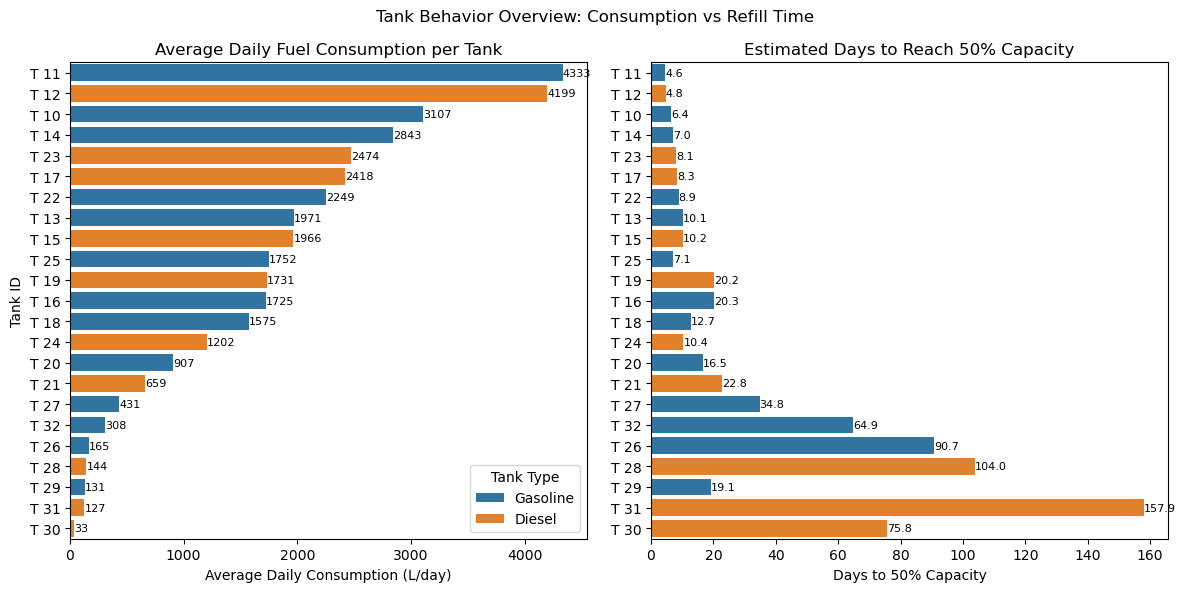

In [51]:
#visualizae avg fuel consumption rate  & estimated days to reach 50% 
fuel_avg = (
    fuel_dec.groupby(['station_location', 'tank_id', 'tank_type2', 'tank_capa', 'min_level'], as_index=False)['diff']
    .mean()
    .rename(columns={'diff': 'avg_daily_consumption'})
)

# Estimated days to reach 50% capacity
fuel_dec2 = (
    fuel_first_last.query('diff < 0')
    .groupby(['tank_id', 'tank_type2', 'min_level'], as_index=False)['diff']
    .mean()
)
fuel_dec2['avg_daily_consumption'] = fuel_dec2['diff'].abs()
fuel_dec2['day_to_min'] = fuel_dec2['min_level'] / fuel_dec2['avg_daily_consumption']

# Merge the two metrics (in case of overlapping tank_ids)
combined = fuel_avg.merge(
    fuel_dec2[['tank_id', 'day_to_min']],
    on='tank_id',
    how='left'
)

# Sort by consumption or days (optional)
combined = combined.sort_values('avg_daily_consumption', ascending=False)

# --- Plot side-by-side subplots ---
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# === Left subplot: Average Daily Fuel Consumption ===
sns.barplot(
    data=combined,
    y='tank_id',
    x='avg_daily_consumption',
    hue='tank_type2',
    #palette='coolwarm',
    dodge=False,
    ax=axes[0]
)
axes[0].set_title('Average Daily Fuel Consumption per Tank')
axes[0].set_xlabel('Average Daily Consumption (L/day)')
axes[0].set_ylabel('Tank ID')
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.0f', label_type='edge', fontsize=8)
axes[0].legend(title='Tank Type', loc='lower right')

# === Right subplot: Days to Reach 50% Capacity ===
sns.barplot(
    data=combined,
    y='tank_id',
    x='day_to_min',
    hue='tank_type2',
    #palette='coolwarm',
    dodge=False,
    ax=axes[1]
)
axes[1].set_title('Estimated Days to Reach 50% Capacity')
axes[1].set_xlabel('Days to 50% Capacity')
axes[1].set_ylabel('')
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f', label_type='edge', fontsize=8)
axes[1].legend_.remove()

plt.suptitle('Tank Behavior Overview: Consumption vs Refill Time')
plt.tight_layout()
plt.savefig('test')

In [52]:
order_new = combined.groupby(['station_location','tank_type2'])['tank_capa'].sum().reset_index().merge(
    combined.groupby(['station_location','tank_type2'])[['day_to_min','avg_daily_consumption']].mean().reset_index(), on = ['station_location', 'tank_type2'],how = 'left'
)
order_new

,station_location,tank_type2,tank_capa,day_to_min,avg_daily_consumption
0,1,Diesel,80000,7.47,3082.37
1,1,Gasoline,160000,7.06,3063.44
2,2,Diesel,110000,14.24,2074.61
3,2,Gasoline,110000,16.49,1650.17
4,3,Diesel,30000,22.76,658.93
5,3,Gasoline,30000,16.53,907.20
6,4,Diesel,40000,8.09,2473.52
7,4,Gasoline,40000,8.89,2249.39
8,5,Diesel,25000,10.40,1202.44
9,5,Gasoline,25000,7.14,1751.67


In [53]:
invoices_df2['cost_per_liter'] = invoices_df2['purchased_cost'] / invoices_df2['purchased_amount']
invoices_df2.head(3)

# calcualte current average cost per liter from invoice data
avg_disc = invoices_df2['cost_per_liter'].mean()
# calculate discount amount per liter
order_new['disc_per'] = order_new['tank_capa'].apply(disc_per)
# calculate total discount if order up to minimum level each time
order_new['disc_total'] = order_new['disc_per'] * order_new['tank_capa']
# calculate cost of ordering up to minimum level before discount
order_new['order_cost'] = (order_new['tank_capa'] * avg_disc)
# calculate cost of ordering up to minimum level after discount
order_new['order_cost_disc'] = (order_new['tank_capa'] * avg_disc)  - order_new['disc_total']
#calculate how many times it will take to order each year according to the estimated use-up day 
order_new['order_days'] = 365 / order_new['day_to_min']
# calculate annual cost of ordering based on daily consumption and using current average cost per liter
order_new['cost_old'] = order_new['avg_daily_consumption'] * avg_disc * 365
#calcualte new cost per liter adjusting for discount
order_new['cost_per_liter_new'] = avg_disc - order_new['disc_per']
#calculate new annual cost
order_new['cost_new'] = order_new['cost_per_liter_new']*order_new['avg_daily_consumption'] * 365
#calculate annual saving cost
order_new['cost_diff'] = order_new['cost_old'] - order_new['cost_new']
order_new

,station_location,tank_type2,tank_capa,day_to_min,avg_daily_consumption,disc_per,disc_total,order_cost,order_cost_disc,order_days,cost_old,cost_per_liter_new,cost_new,cost_diff
0,1,Diesel,80000,7.47,3082.37,0.04,3200.0,96832.48,93632.48,48.87,1.36e+06,1.17,1.32e+06,45002.67
1,1,Gasoline,160000,7.06,3063.44,0.04,6400.0,193664.97,187264.97,51.71,1.35e+06,1.17,1.31e+06,44726.17
2,2,Diesel,110000,14.24,2074.61,0.04,4400.0,133144.66,128744.66,25.62,9.17e+05,1.17,8.86e+05,30289.24
3,2,Gasoline,110000,16.49,1650.17,0.04,4400.0,133144.66,128744.66,22.13,7.29e+05,1.17,7.05e+05,24092.50
4,3,Diesel,30000,22.76,658.93,0.03,900.0,36312.18,35412.18,16.03,2.91e+05,1.18,2.84e+05,7215.28
5,3,Gasoline,30000,16.53,907.20,0.03,900.0,36312.18,35412.18,22.08,4.01e+05,1.18,3.91e+05,9933.88
6,4,Diesel,40000,8.09,2473.52,0.03,1200.0,48416.24,47216.24,45.14,1.09e+06,1.18,1.07e+06,27085.05
7,4,Gasoline,40000,8.89,2249.39,0.03,1200.0,48416.24,47216.24,41.05,9.94e+05,1.18,9.69e+05,24630.78
8,5,Diesel,25000,10.40,1202.44,0.02,500.0,30260.15,29760.15,35.11,5.31e+05,1.19,5.22e+05,8777.80
9,5,Gasoline,25000,7.14,1751.67,0.02,500.0,30260.15,29760.15,51.15,7.74e+05,1.19,7.61e+05,12787.21


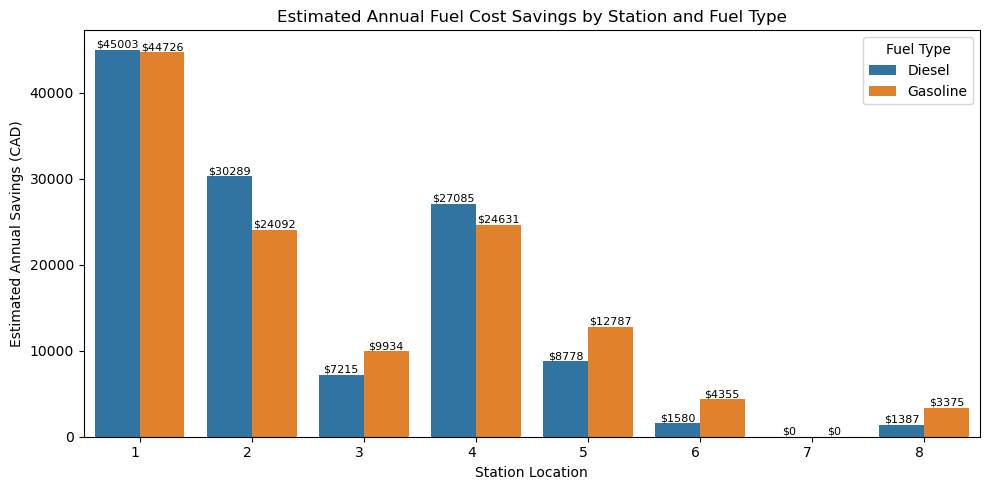

In [54]:
plt.figure(figsize=(10,5))
sns.barplot(
    data=order_new,
    x='station_location',
    y='cost_diff',
    hue='tank_type2',
)

plt.title('Estimated Annual Fuel Cost Savings by Station and Fuel Type')
plt.xlabel('Station Location')
plt.ylabel('Estimated Annual Savings (CAD)')
plt.xticks(rotation=0, ha='right')
plt.legend(title='Fuel Type')

# Add value labels on bars
ax = plt.gca()
for container in ax.containers:
    ax.bar_label(container, fmt='$%.0f', label_type='edge', fontsize=8)

plt.tight_layout()
plt.show()

# `4b` Examine the distribution of price-per-liter rates by day of the week. 

In [55]:
# add columns in invoice_df2 to extract the year, month and day of the week corresponding to the date on the invoice.
invoices_df2.info()
invoices_df2['Year'] = invoices_df2['invoice_date'].dt.year
invoices_df2['Month'] = invoices_df2['invoice_date'].dt.month
invoices_df2['Day_dig'] = invoices_df2['invoice_date'].dt.dayofweek
invoices_df2['Weekday'] = invoices_df2['invoice_date'].dt.day_name()
invoices_df2.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2831 entries, 0 to 2830
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   index             2831 non-null   int64         
 1   invoice_date      2831 non-null   datetime64[ns]
 2   invoice_id        2831 non-null   float64       
 3   station_location  2831 non-null   int64         
 4   purchased_cost    2831 non-null   float64       
 5   purchased_amount  2831 non-null   float64       
 6   tank_type1        2831 non-null   object        
 7   tank_type2        2831 non-null   object        
 8   Year              2831 non-null   int32         
 9   Month             2831 non-null   int32         
 10  Day               2831 non-null   int32         
 11  Day_dig           2831 non-null   int32         
 12  Weekday           2831 non-null   object        
 13  price_per_liter   2831 non-null   float64       
 14  year_month        2831 n

,index,invoice_date,invoice_id,station_location,purchased_cost,purchased_amount,tank_type1,tank_type2,Year,Month,Day,Day_dig,Weekday,price_per_liter,year_month,disc_per_liter,disc_total,cost_per_liter
0,0,2017-01-02,10000.0,1,7570.82,6609.60,G,Gasoline,2017,1,2,0,Monday,1.15,2017-01,0.0,0.0,1.15
1,1,2017-01-02,10001.0,1,12491.85,9338.74,D,Diesel,2017,1,2,0,Monday,1.34,2017-01,0.0,0.0,1.34
2,3,2017-01-02,10002.0,2,17034.35,13377.82,D,Diesel,2017,1,2,0,Monday,1.27,2017-01,0.0,0.0,1.27
3,5,2017-01-02,10003.0,2,12616.77,9432.11,D,Diesel,2017,1,2,0,Monday,1.34,2017-01,0.0,0.0,1.34
4,6,2017-01-02,10004.0,4,11363.80,9139.20,D,Diesel,2017,1,2,0,Monday,1.24,2017-01,0.0,0.0,1.24


In [56]:
# Count the number of occurrences of each weekday in the 'Weekday' column
invoices_df2['Weekday'].value_counts()

Weekday
Friday       803
Wednesday    606
Tuesday      549
Monday       522
Thursday     338
Saturday      13
Name: count, dtype: int64

In [57]:
# Count the number of invoices for each gas station location
invoices_df2['station_location'].value_counts()

station_location
1    1361
2     632
4     356
5     280
3      80
7      52
6      42
8      28
Name: count, dtype: int64

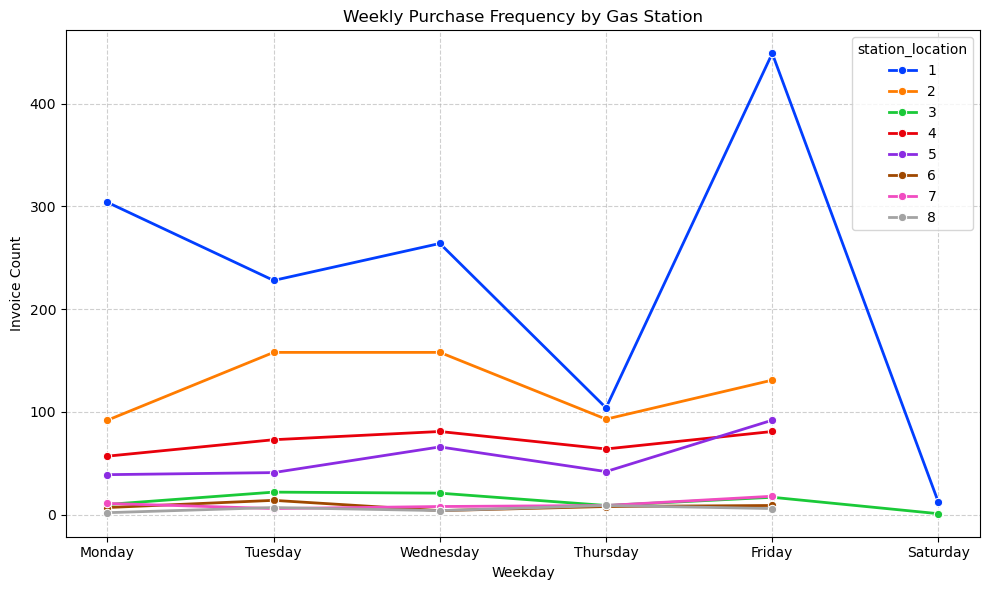

In [58]:
# Count the number of invoices per station per weekday, and ensure weekday order is correct from Monday to Saturday
station_weekday = invoices_df2.groupby(['station_location', 'Weekday']).size().reset_index(name='Count')
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
station_weekday['Weekday'] = pd.Categorical(station_weekday['Weekday'], categories=weekday_order, ordered=True)

# Plot line chart
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=station_weekday,
    x='Weekday',
    y='Count',
    hue='station_location',
    palette = 'bright',
    marker='o',             
    linewidth=2
)

# Setting the Format
plt.title('Weekly Purchase Frequency by Gas Station')
plt.xlabel('Weekday')
plt.ylabel('Invoice Count')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [59]:
# Since Saturdays appear only 13 times in three years and have the lowest average fuel prices, 
# they are excluded when calculating the lowest price and determining the ideal cost.
invoice_df_withoutSaturday = invoices_df2[invoices_df2['Weekday'] != 'Saturday']

In [60]:
# Calculate the fuel price per liter for each transaction in the full invoice dataset
# The price per liter is obtained by dividing the total purchase cost by the purchased amount.
invoices_df2['price_per_liter'] = invoices_df2['purchased_cost']/invoices_df2['purchased_amount']
invoice_df_withoutSaturday['price_per_liter'] = invoice_df_withoutSaturday['purchased_cost']/invoice_df_withoutSaturday['purchased_amount']
invoice_df_withoutSaturday.head()

/var/folders/nr/x6d82jnx1pn04_gdb8vr44sr0000gn/T/ipykernel_73119/2663133055.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  invoice_df_withoutSaturday['price_per_liter'] = invoice_df_withoutSaturday['purchased_cost']/invoice_df_withoutSaturday['purchased_amount']


,index,invoice_date,invoice_id,station_location,purchased_cost,purchased_amount,tank_type1,tank_type2,Year,Month,Day,Day_dig,Weekday,price_per_liter,year_month,disc_per_liter,disc_total,cost_per_liter
0,0,2017-01-02,10000.0,1,7570.82,6609.60,G,Gasoline,2017,1,2,0,Monday,1.15,2017-01,0.0,0.0,1.15
1,1,2017-01-02,10001.0,1,12491.85,9338.74,D,Diesel,2017,1,2,0,Monday,1.34,2017-01,0.0,0.0,1.34
2,3,2017-01-02,10002.0,2,17034.35,13377.82,D,Diesel,2017,1,2,0,Monday,1.27,2017-01,0.0,0.0,1.27
3,5,2017-01-02,10003.0,2,12616.77,9432.11,D,Diesel,2017,1,2,0,Monday,1.34,2017-01,0.0,0.0,1.34
4,6,2017-01-02,10004.0,4,11363.80,9139.20,D,Diesel,2017,1,2,0,Monday,1.24,2017-01,0.0,0.0,1.24


In [61]:
# Examine the distribution of price-per-liter rates by day of the week. 
# shows the average daily fuel price trend for each year and fuel type, helping identify patterns such as weekday price fluctuations.
Distribution_1 = invoices_df2.pivot_table(values = 'price_per_liter',
                                          index = ['Year','tank_type1'],
                                          columns = 'Day_dig',
                                        aggfunc = 'mean')

# To arrange the columns in Monday-to-Friday order, the column names in the original table were renamed.
Weekdays = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
Distribution_1.columns = Weekdays
Distribution_1

Monday  Tuesday  Wednesday  Thursday  Friday  Saturday
Year tank_type1                                                        
2017 D             1.18     1.17       1.16      1.17    1.15      1.17
     G             1.03     1.07       1.05      1.03    1.05      1.08
2018 D             1.07     1.07       1.06      1.07    1.07      1.07
     G             1.03     1.05       1.04      1.03    1.04      0.96
2019 D             1.79     1.91       1.82      1.90    1.83       NaN
     G             1.46     1.67       1.47      1.53    1.57       NaN

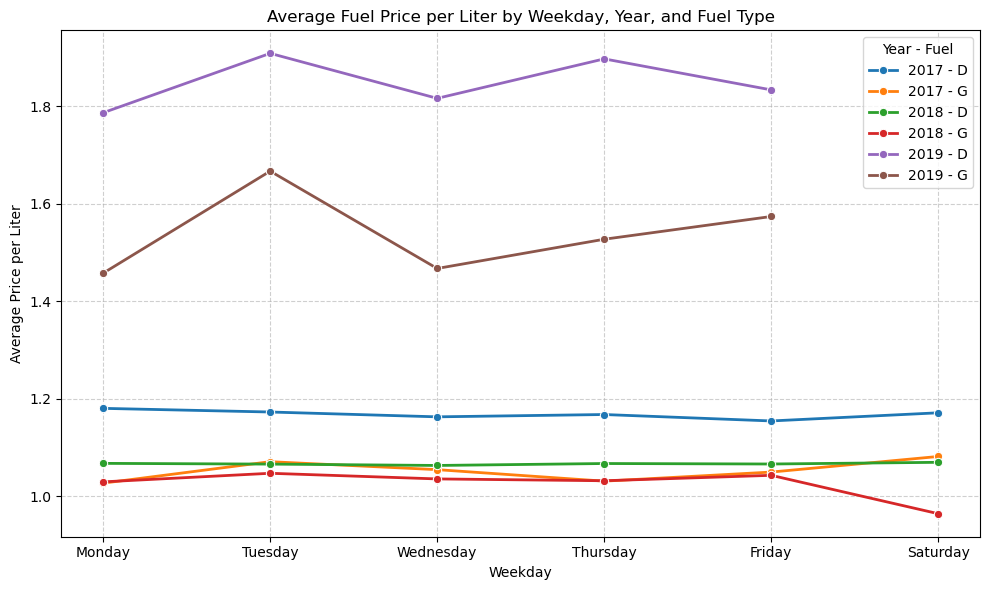

In [62]:
# Reshape pivot table for plotting, and create a combined label for legend
Distribution_1_reset = Distribution_1.reset_index().melt(
    id_vars=['Year', 'tank_type1'],
    var_name='Weekday',
    value_name='Avg_Price_per_Liter')
Distribution_1_reset['Label'] = (
    Distribution_1_reset['Year'].astype(str) + ' - ' + Distribution_1_reset['tank_type1'])

# Make a line plot
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=Distribution_1_reset,
    x='Weekday',
    y='Avg_Price_per_Liter',
    hue='Label',        
    marker='o',
    linewidth=2
)

# set the formats
plt.title('Average Fuel Price per Liter by Weekday, Year, and Fuel Type')
plt.xlabel('Weekday')
plt.ylabel('Average Price per Liter')
plt.legend(title='Year - Fuel')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [63]:
# Calculate the average fuel price per liter by weekday, year, and fuel type (excluding Saturday)
Distribution_of_price = invoice_df_withoutSaturday.pivot_table(values = 'price_per_liter',
                                                                index = ['Year', 'tank_type1'],
                                                                columns = 'Day_dig',
                                                                aggfunc = 'mean')
Distribution_of_price

Day_dig             0     1     2     3     4
Year tank_type1                              
2017 D           1.18  1.17  1.16  1.17  1.15
     G           1.03  1.07  1.05  1.03  1.05
2018 D           1.07  1.07  1.06  1.07  1.07
     G           1.03  1.05  1.04  1.03  1.04
2019 D           1.79  1.91  1.82  1.90  1.83
     G           1.46  1.67  1.47  1.53  1.57

In [64]:
# To arrange the columns in Monday-to-Friday order, the column names in the original table were renamed.
Weekdays = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
Distribution_of_price.columns = Weekdays

In [65]:
Distribution_of_price

Monday  Tuesday  Wednesday  Thursday  Friday
Year tank_type1                                              
2017 D             1.18     1.17       1.16      1.17    1.15
     G             1.03     1.07       1.05      1.03    1.05
2018 D             1.07     1.07       1.06      1.07    1.07
     G             1.03     1.05       1.04      1.03    1.04
2019 D             1.79     1.91       1.82      1.90    1.83
     G             1.46     1.67       1.47      1.53    1.57

In [66]:
# Eliminate scientific notation
pd.set_option('display.float_format', '{:.2f}'.format)

In [67]:
# Calculate the growth rate of average fuel prices (per liter) across years for each weekday
Growth_Rate = Distribution_of_price.iloc[2:6, :].copy()
for i in range(4):
    for j in range(5):
        Growth_Rate.iloc[i,j] = (Distribution_of_price.iloc[i+2,j] - Distribution_of_price.iloc[i,j])/ Distribution_of_price.iloc[i,j]
Growth_Rate

Monday  Tuesday  Wednesday  Thursday  Friday
Year tank_type1                                              
2018 D            -0.10    -0.09      -0.09     -0.09   -0.08
     G             0.00    -0.02      -0.02      0.00   -0.01
2019 D             0.67     0.79       0.71      0.78    0.72
     G             0.42     0.59       0.42      0.48    0.51

# `4b` & `5b` Calculate additional savings if purchases were consistently made on the identified day.

In [68]:
# Calculate the actual cost of each gas station from 2017-2019
actual_total_cost = invoices_df2.pivot_table(values = 'purchased_cost',
                                             index = ['Year','tank_type1'],
                                             columns = 'station_location',
                                             aggfunc = 'sum')
actual_total_cost

station_location          1          2         3         4         5  \
Year tank_type1                                                        
2017 D           2282132.84 1747227.91 217827.63 685647.53 377492.44   
     G           4844086.97 1292876.50 245688.25 623756.07 593340.31   
2018 D           2238895.89 1702109.61 202496.72 795765.10 368793.57   
     G           4749693.99 1305788.54 146752.77 721434.79 543357.75   
2019 D           1375530.93  566210.27  72653.37 486148.85 248394.82   
     G           2708612.27  441337.17  54888.44 385581.86 350990.79   

station_location         6        7        8  
Year tank_type1                               
2017 D            25396.32  3955.75 43350.52  
     G           185053.55 31967.79 83309.30  
2018 D            26611.43  6825.09 26630.36  
     G           153339.39 44285.51 90690.85  
2019 D            14009.80  2415.09 17503.74  
     G            81363.60 27906.04 58598.15

In [69]:
# Identify the weekday with the lowest average fuel price for each year and fuel type
Lowest_Day = pd.DataFrame(Distribution_of_price.idxmin(axis = 1))
Lowest_Day.rename(columns = {0:'Weekday'}, inplace = True)
Lowest_Day

Weekday
Year tank_type1           
2017 D              Friday
     G              Monday
2018 D           Wednesday
     G              Monday
2019 D              Monday
     G              Monday

In [70]:
# Find the lowest average fuel price (per liter) for each year and fuel type across all weekdays
Lowest_Price = pd.DataFrame(Distribution_of_price.min(axis = 1))
Lowest_Price.rename(columns = {0:'Price'}, inplace = True)
Lowest_Price

Price
Year tank_type1       
2017 D            1.15
     G            1.03
2018 D            1.06
     G            1.03
2019 D            1.79
     G            1.46

In [71]:
# Add a new column 'Price' to the Lowest_Day DataFrame,
# containing the corresponding lowest average fuel price for each year and fuel type 
Lowest_Day['Price'] = Lowest_Price['Price']
Lowest_Day

Weekday  Price
Year tank_type1                  
2017 D              Friday   1.15
     G              Monday   1.03
2018 D           Wednesday   1.06
     G              Monday   1.03
2019 D              Monday   1.79
     G              Monday   1.46

In [72]:
# Create a pivot table to show the total fuel purchased (in liters) 
# for each combination of year and fuel type across different gas stations
actual_purchase = invoices_df2.pivot_table(values = 'purchased_amount',
                                             index = ['Year','tank_type1'],
                                             columns = 'station_location',
                                             aggfunc = 'sum')
actual_purchase

station_location          1          2         3         4         5  \
Year tank_type1                                                        
2017 D           1989594.99 1516858.16 188074.51 602359.78 324889.60   
     G           4559836.38 1244200.59 237274.72 604630.56 573679.18   
2018 D           2102321.31 1594656.85 189560.61 746847.86 345018.10   
     G           4489192.96 1268268.18 143116.72 700341.31 528261.62   
2019 D            780541.73  349384.80  54180.00 283260.80 141826.26   
     G           1817181.87  310045.01  43127.22 273645.90 244772.02   

station_location         6        7        8  
Year tank_type1                               
2017 D            21753.57  3554.85 41262.29  
     G           178205.57 31823.54 79396.91  
2018 D            25196.13  6367.10 25182.00  
     G           148720.94 42936.18 87537.30  
2019 D             7680.26  1160.32  9606.54  
     G            59753.58 18803.10 40808.30

In [73]:
# Add a new column 'ideal price_per_liter' to the actual_purchase DataFrame,
# containing the corresponding lowest average fuel price for each year and fuel type
actual_purchase['ideal price_per_liter'] = Lowest_Day['Price']

In [74]:
actual_purchase

station_location          1          2         3         4         5  \
Year tank_type1                                                        
2017 D           1989594.99 1516858.16 188074.51 602359.78 324889.60   
     G           4559836.38 1244200.59 237274.72 604630.56 573679.18   
2018 D           2102321.31 1594656.85 189560.61 746847.86 345018.10   
     G           4489192.96 1268268.18 143116.72 700341.31 528261.62   
2019 D            780541.73  349384.80  54180.00 283260.80 141826.26   
     G           1817181.87  310045.01  43127.22 273645.90 244772.02   

station_location         6        7        8  ideal price_per_liter  
Year tank_type1                                                      
2017 D            21753.57  3554.85 41262.29                   1.15  
     G           178205.57 31823.54 79396.91                   1.03  
2018 D            25196.13  6367.10 25182.00                   1.06  
     G           148720.94 42936.18 87537.30                   1.03  
2019 D             7680.26  1160.32  9606.54                   1.79  
     G            59753.58 18803.10 40808.30                   1.46

In [75]:
# we previously calculated which day of the week had the lowest price, then obtained the price. 
# The ideal cost is the actual volume of fuel purchased multiplied by the lowest price of the week, 
# yielding the ideal purchase price.
ideal_total_cost = actual_purchase.iloc[:,0:8]
for i in range(6):
    ideal_total_cost.iloc[i, 0:8] = actual_purchase.iloc[i, 0:8] * actual_purchase.iloc[i, 8]

In [76]:
ideal_total_cost

station_location          1          2         3         4         5  \
Year tank_type1                                                        
2017 D           2297587.08 1751669.92 217188.71 695605.91 375182.96   
     G           4683955.03 1278067.71 243733.33 621088.59 589294.72   
2018 D           2235797.97 1695901.82 201595.84 794265.32 366923.34   
     G           4623046.93 1306084.05 147384.02 721223.34 544012.76   
2019 D           1394973.06  624415.54  96829.72 506239.67 253469.86   
     G           2649426.13  452041.35  62878.89 398971.96 356874.23   

station_location         6        7        8  
Year tank_type1                               
2017 D            25121.05  4105.14 47649.75  
     G           183056.32 32689.77 81558.09  
2018 D            26795.83  6771.35 26780.81  
     G           153155.35 44216.40 90147.39  
2019 D            13726.04  2073.71 17168.68  
     G            87119.90 27414.67 59497.94

In [77]:
# Compute the cost difference between the actual total cost and the ideal total cost
# for each year (row) and each gas station (column)
cost_difference = ideal_total_cost.copy()
for i in range(6):
    for j in range(8):
        cost_difference.iloc[i,j] = actual_total_cost.iloc[i,j] - ideal_total_cost.iloc[i,j] 

In [78]:
cost_difference

station_location         1         2         3         4        5        6  \
Year tank_type1                                                              
2017 D           -15454.24  -4442.01    638.92  -9958.38  2309.48   275.26   
     G           160131.94  14808.80   1954.92   2667.48  4045.59  1997.23   
2018 D             3097.92   6207.79    900.89   1499.78  1870.23  -184.40   
     G           126647.05   -295.51   -631.25    211.45  -655.01   184.04   
2019 D           -19442.13 -58205.27 -24176.35 -20090.82 -5075.05   283.76   
     G            59186.14 -10704.18  -7990.44 -13390.09 -5883.44 -5756.30   

station_location       7        8  
Year tank_type1                    
2017 D           -149.39 -4299.23  
     G           -721.98  1751.21  
2018 D             53.74  -150.45  
     G             69.11   543.46  
2019 D            341.38   335.06  
     G            491.38  -899.80

In [79]:
# # Generate descriptive statistics for the invoices_df2 DataFrame
invoices_df2.describe()

,index,invoice_date,invoice_id,station_location,purchased_cost,purchased_amount,Year,Month,Day,Day_dig,price_per_liter,disc_per_liter,disc_total,cost_per_liter
count,2831.00,2831,2831.00,2831.00,2831.00,2831.00,2831.00,2831.00,2831.00,2831.00,2831.00,2831.00,2831.00,2831.00
mean,1444.84,2018-04-09 13:01:48.089014528,11415.00,2.31,11762.18,10270.82,2017.82,5.92,15.39,2.14,1.21,0.00,72.76,1.21
min,0.00,2017-01-02 00:00:00,10000.00,1.00,94.64,96.98,2017.00,1.00,1.00,0.00,0.88,0.00,0.00,0.88
25%,732.50,2017-08-09 00:00:00,10707.50,1.00,8327.90,7073.38,2017.00,3.00,8.00,1.00,1.02,0.00,0.00,1.02
50%,1448.00,2018-04-06 00:00:00,11415.00,2.00,10459.09,9262.30,2018.00,6.00,15.00,2.00,1.06,0.00,0.00,1.06
75%,2161.50,2018-11-28 00:00:00,12122.50,4.00,12518.35,11435.98,2018.00,8.00,23.00,4.00,1.22,0.00,0.00,1.22
max,2872.00,2019-08-15 00:00:00,12830.00,8.00,33118.55,33826.56,2019.00,12.00,31.00,5.00,3.24,0.03,1014.80,3.24
std,827.64,NaN,817.38,1.69,6562.63,6101.91,0.76,3.31,8.83,1.49,0.34,0.01,221.31,0.34
